# IBM Sentiment Bias Audit for Paper Claims

This notebook is a focused audit of the IBM topic-level sentiment result story. It keeps the paper-relevant evidence and avoids the longer annotation-heavy analysis from `analysis-ibm-sentiment.ipynb`.

Questions addressed here:

- Do persona-conditioned models differ meaningfully from `base` and `centrism`?
- When do `libertarian`, `left`, `authoritarian`, or `right` persona groupings work or fail relative to those references?
- Are the differences concentrated in the 30 target labels themselves, or in broad target axes: `Social`, `Economic`, `Political`, and `Cross-cutting`?
- Is the observation that authoritarian/right personas do better than libertarian/left personas defensible, or mostly a small unstable artifact?

Important scope note: IBM sentiment has 30 unique topic-level sentiment items. Every topic receives 300 LHS prompt configurations per `(model, ideology)` block. Statistical tests below therefore treat topics as the conservative unit of analysis and report model-consistency diagnostics separately. The results are useful for narrative discipline in the paper, not for strong causal claims about ideological groups.

In [15]:
import os
import sys
import warnings
from pathlib import Path


def resolve_stance_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "tasks" / "stance-sentiment",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "mcq.py").exists() and (candidate / "output" / "ibm-sentiment").exists():
            return candidate
    raise FileNotFoundError("Could not locate tasks/stance-sentiment root")


STANCE_ROOT = resolve_stance_root()
MPL_CACHE_DIR = STANCE_ROOT / "output" / ".matplotlib-cache"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(STANCE_ROOT / "output" / ".cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")

SOURCE_OUTPUT = STANCE_ROOT / "output" / "ibm-sentiment"
SOURCE_TABLES = SOURCE_OUTPUT / "tables"
SOURCE_PLOTS = SOURCE_OUTPUT / "plots"

OUTPUT_DIR = STANCE_ROOT / "output" / "ibm-sentiment-bias-paper"
TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "gemma-3-1b-it",
    "gemma-3-4b-it",
    "gemma-3-12b-it",
    "gemma-3-27b-it",
    "Qwen3-4B",
    "Qwen3-8B",
    "Qwen3-14B",
    "Qwen3-32B",
]

IDEOLOGY_ORDER = [
    "base",
    "centrism",
    "libertarian_left",
    "libertarian_right",
    "authoritarian_left",
    "authoritarian_right",
]

IDEOLOGY_LABELS = {
    "base": "Base",
    "centrism": "Center",
    "libertarian_left": "Lib Left",
    "libertarian_right": "Lib Right",
    "authoritarian_left": "Auth Left",
    "authoritarian_right": "Auth Right",
}

AXIS_ORDER = ["Social", "Economic", "Political", "Cross-cutting", "Unmapped"]
AXIS_COLORS = {
    "Social": "#4C78A8",
    "Economic": "#F58518",
    "Political": "#54A24B",
    "Cross-cutting": "#B279A2",
    "Unmapped": "#9E9E9E",
}

GROUP_COLORS = {
    "Base": "#4D4D4D",
    "Center": "#7F7F7F",
    "Libertarian": "#5DA5DA",
    "Authoritarian": "#E15759",
    "Left": "#59A14F",
    "Right": "#B07AA1",
}

print(f"STANCE_ROOT={STANCE_ROOT}")
print(f"SOURCE_TABLES={SOURCE_TABLES}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")

STANCE_ROOT=tasks/stance-sentiment
SOURCE_TABLES=tasks/stance-sentiment/output/ibm-sentiment/tables
OUTPUT_DIR=tasks/stance-sentiment/output/ibm-sentiment-bias-paper


In [16]:
def read_source_table(name: str) -> pd.DataFrame:
    path = SOURCE_TABLES / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required table: {path}")
    return pd.read_csv(path)


def write_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLES_DIR / name
    df.to_csv(path, index=False)
    return path


def show_source_plot(name: str) -> None:
    path = SOURCE_PLOTS / name
    if path.exists():
        display(Markdown(f"**Existing plot: `{name}`**"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"`{name}` not found in `{SOURCE_PLOTS}`."))


def show_bias_plot(name: str) -> None:
    path = PLOTS_DIR / name
    if path.exists():
        display(Markdown(f"**Bias-audit plot: `{name}`**"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"`{name}` not found in `{PLOTS_DIR}`."))


def show_table(df: pd.DataFrame, n: int = 20, sort_by: str | None = None, ascending: bool = False) -> None:
    out = df.copy()
    if sort_by and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending=ascending)
    display(out.head(n))


summary_model = read_source_table("summary_by_model.csv")
summary_ideology = read_source_table("summary_by_model_ideology.csv")
item_acc = read_source_table("item_accuracy_by_model_persona.csv")
threshold_target = read_source_table("threshold_metrics_by_target.csv")
target_mapping = read_source_table("target_mapping.csv")

required_item_cols = {
    "model", "ideology", "item_index", "item_accuracy", "target", "axis",
    "domain", "keyword_primary_label", "gold_label",
}
missing = required_item_cols - set(item_acc.columns)
if missing:
    raise ValueError(f"`item_accuracy_by_model_persona.csv` is missing columns: {sorted(missing)}")

item_acc["model"] = pd.Categorical(item_acc["model"].astype(str), categories=MODEL_ORDER, ordered=True)
item_acc["ideology"] = pd.Categorical(item_acc["ideology"].astype(str), categories=IDEOLOGY_ORDER, ordered=True)
item_acc["axis"] = item_acc["axis"].fillna("Unmapped").astype(str)
item_acc["target"] = item_acc["target"].astype(str)
item_acc["gold_label"] = item_acc["gold_label"].astype(str)

print(f"Loaded {len(item_acc):,} model/persona/topic rows.")
print(f"Unique models: {item_acc['model'].nunique()}")
print(f"Unique ideologies: {item_acc['ideology'].nunique()}")
print(f"Unique sentiment topics: {item_acc['item_index'].nunique()}")
display(item_acc.groupby(["axis", "gold_label"], observed=True)["item_index"].nunique().reset_index(name="n_topics"))

Loaded 1,440 model/persona/topic rows.
Unique models: 8
Unique ideologies: 6
Unique sentiment topics: 30


,axis,gold_label,n_topics
0,Cross-cutting,POSITIVE,4
1,Economic,NEGATIVE,3
2,Economic,POSITIVE,2
3,Political,NEGATIVE,2
4,Political,POSITIVE,5
5,Social,NEGATIVE,6
6,Social,POSITIVE,8


## Paper-Facing Figure Story

This is the compact figure sequence that should guide the paper narrative.

1. **Persona heatmap:** base and center are strongest; ideological personas usually reduce macro-F1.
2. **Overall pairwise deltas:** the main contrast is not "authoritarian/right are better"; it is that all ideological persona families are worse than base/center, while auth-vs-lib and right-vs-left are small relative comparisons between degraded conditions.
3. **Axis pairwise deltas:** political/economic topics explain the relative auth-over-lib direction, while social and cross-cutting topics dampen or reverse it.
4. **Factor sensitivity:** IBM sentiment is prompt-sensitive beyond persona alone; instruction, context, key type, permutation, and residual configuration variance also matter.

The target-level direction plot is kept as an appendix diagnostic. The target accuracy heatmap is intentionally not part of this story because it is too dense and answers a less focused question.

### 1. Persona Heatmap: Absolute Macro-F1 by Model and Persona

Read this as the direct model/persona performance table. The bright-to-dim pattern is real: base and center are strongest, while ideological personas generally lower macro-F1.

**Existing plot: `02_macro_f1_model_persona_heatmap.png`**

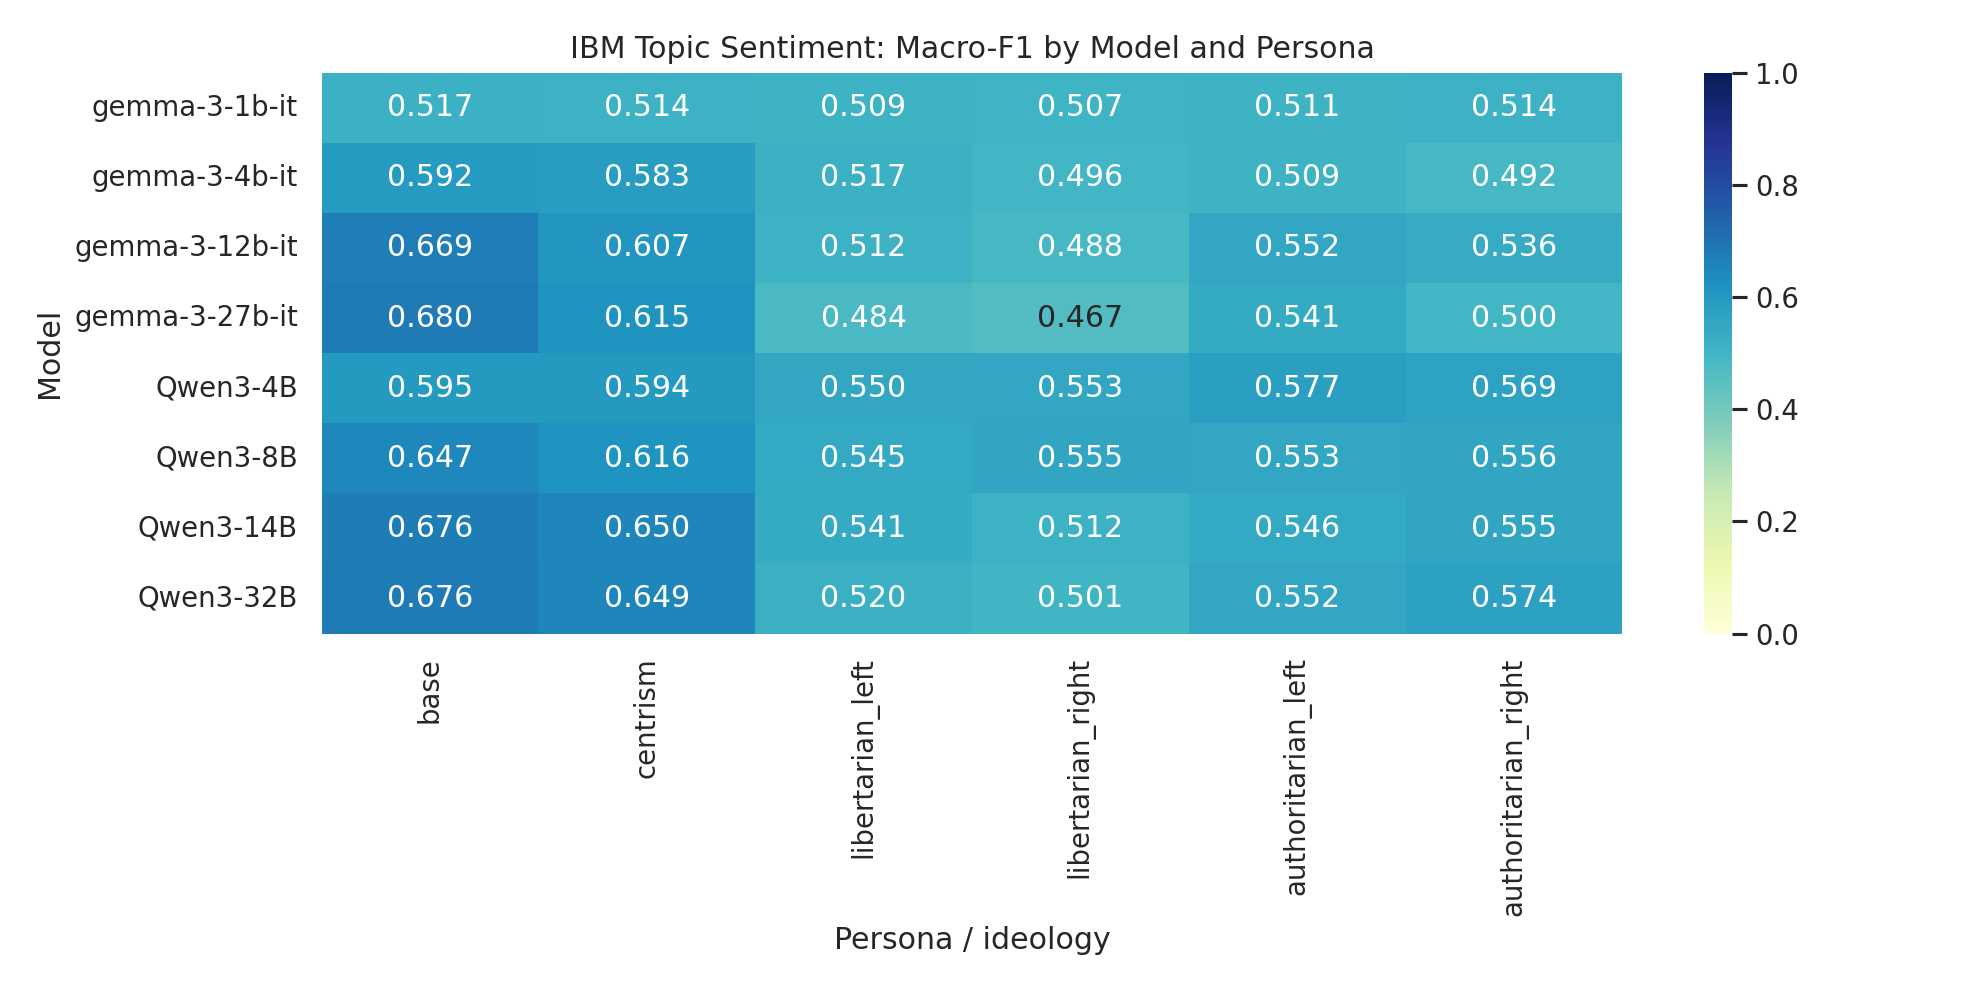

### 2. Overall Pairwise Deltas: What Changes Relative to Base/Center?

These bars use topic-level accuracy deltas. Negative bars mean the left-hand condition is worse than the reference. `Authoritarian - Libertarian` is a comparison between two already-degraded persona families, not a comparison against base.

**Bias-audit plot: `01_overall_pairwise_topic_deltas.png`**

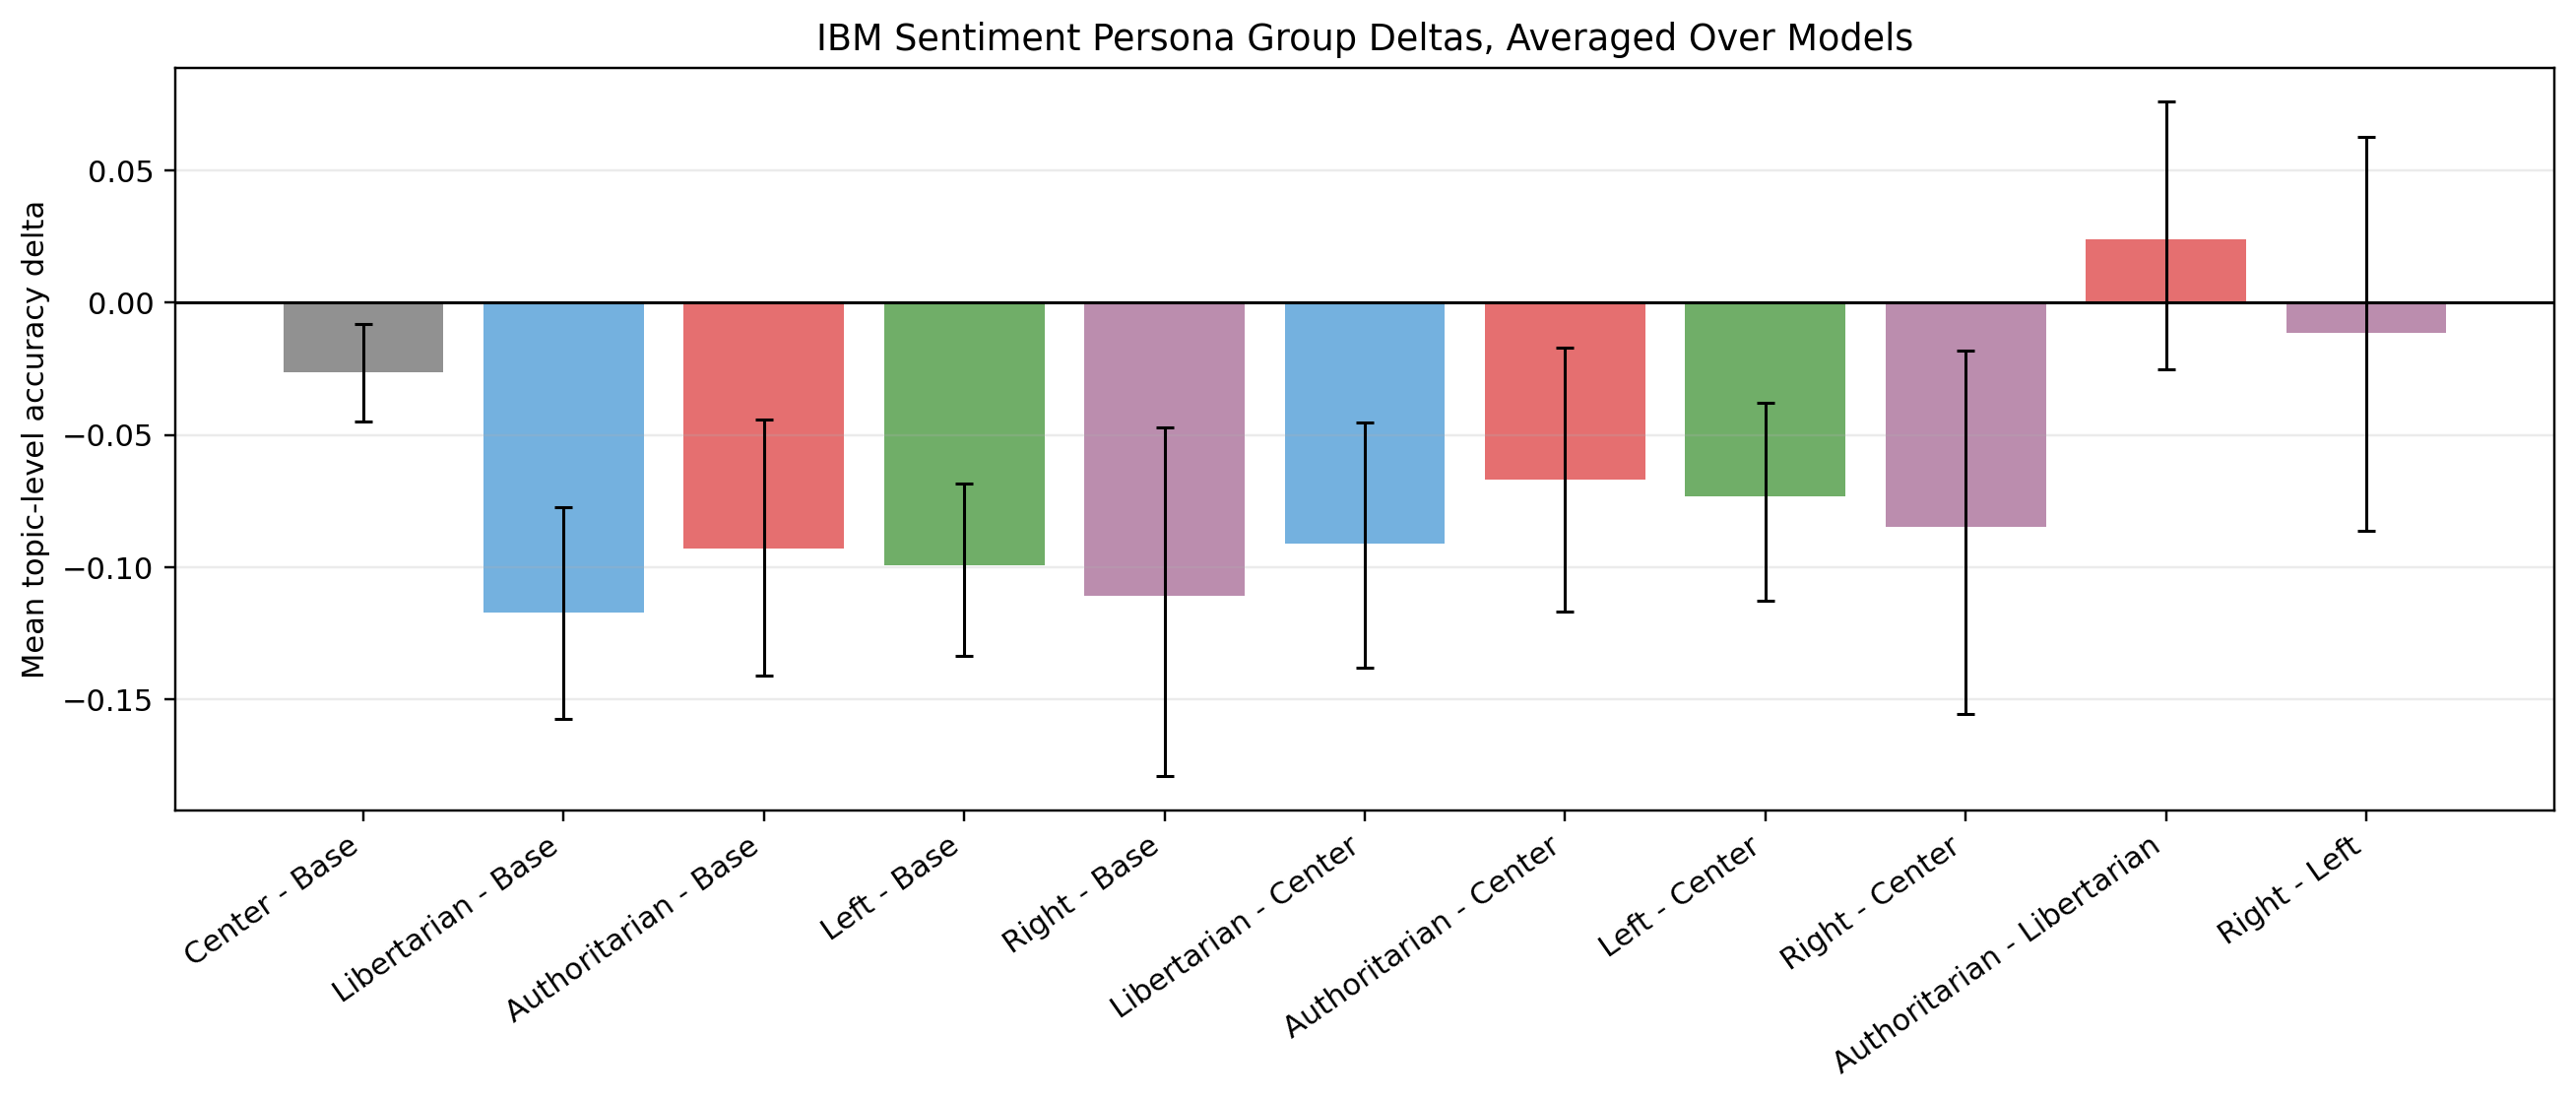

### 3. Axis Pairwise Deltas: Where Does the Relative Direction Come From?

Political and economic topics push `Authoritarian - Libertarian` upward, while Social and Cross-cutting topics dampen it. Support is uneven: Social has 14 topics, Political 7, Economic 5, Cross-cutting 4.

**Bias-audit plot: `02_axis_pairwise_topic_deltas.png`**

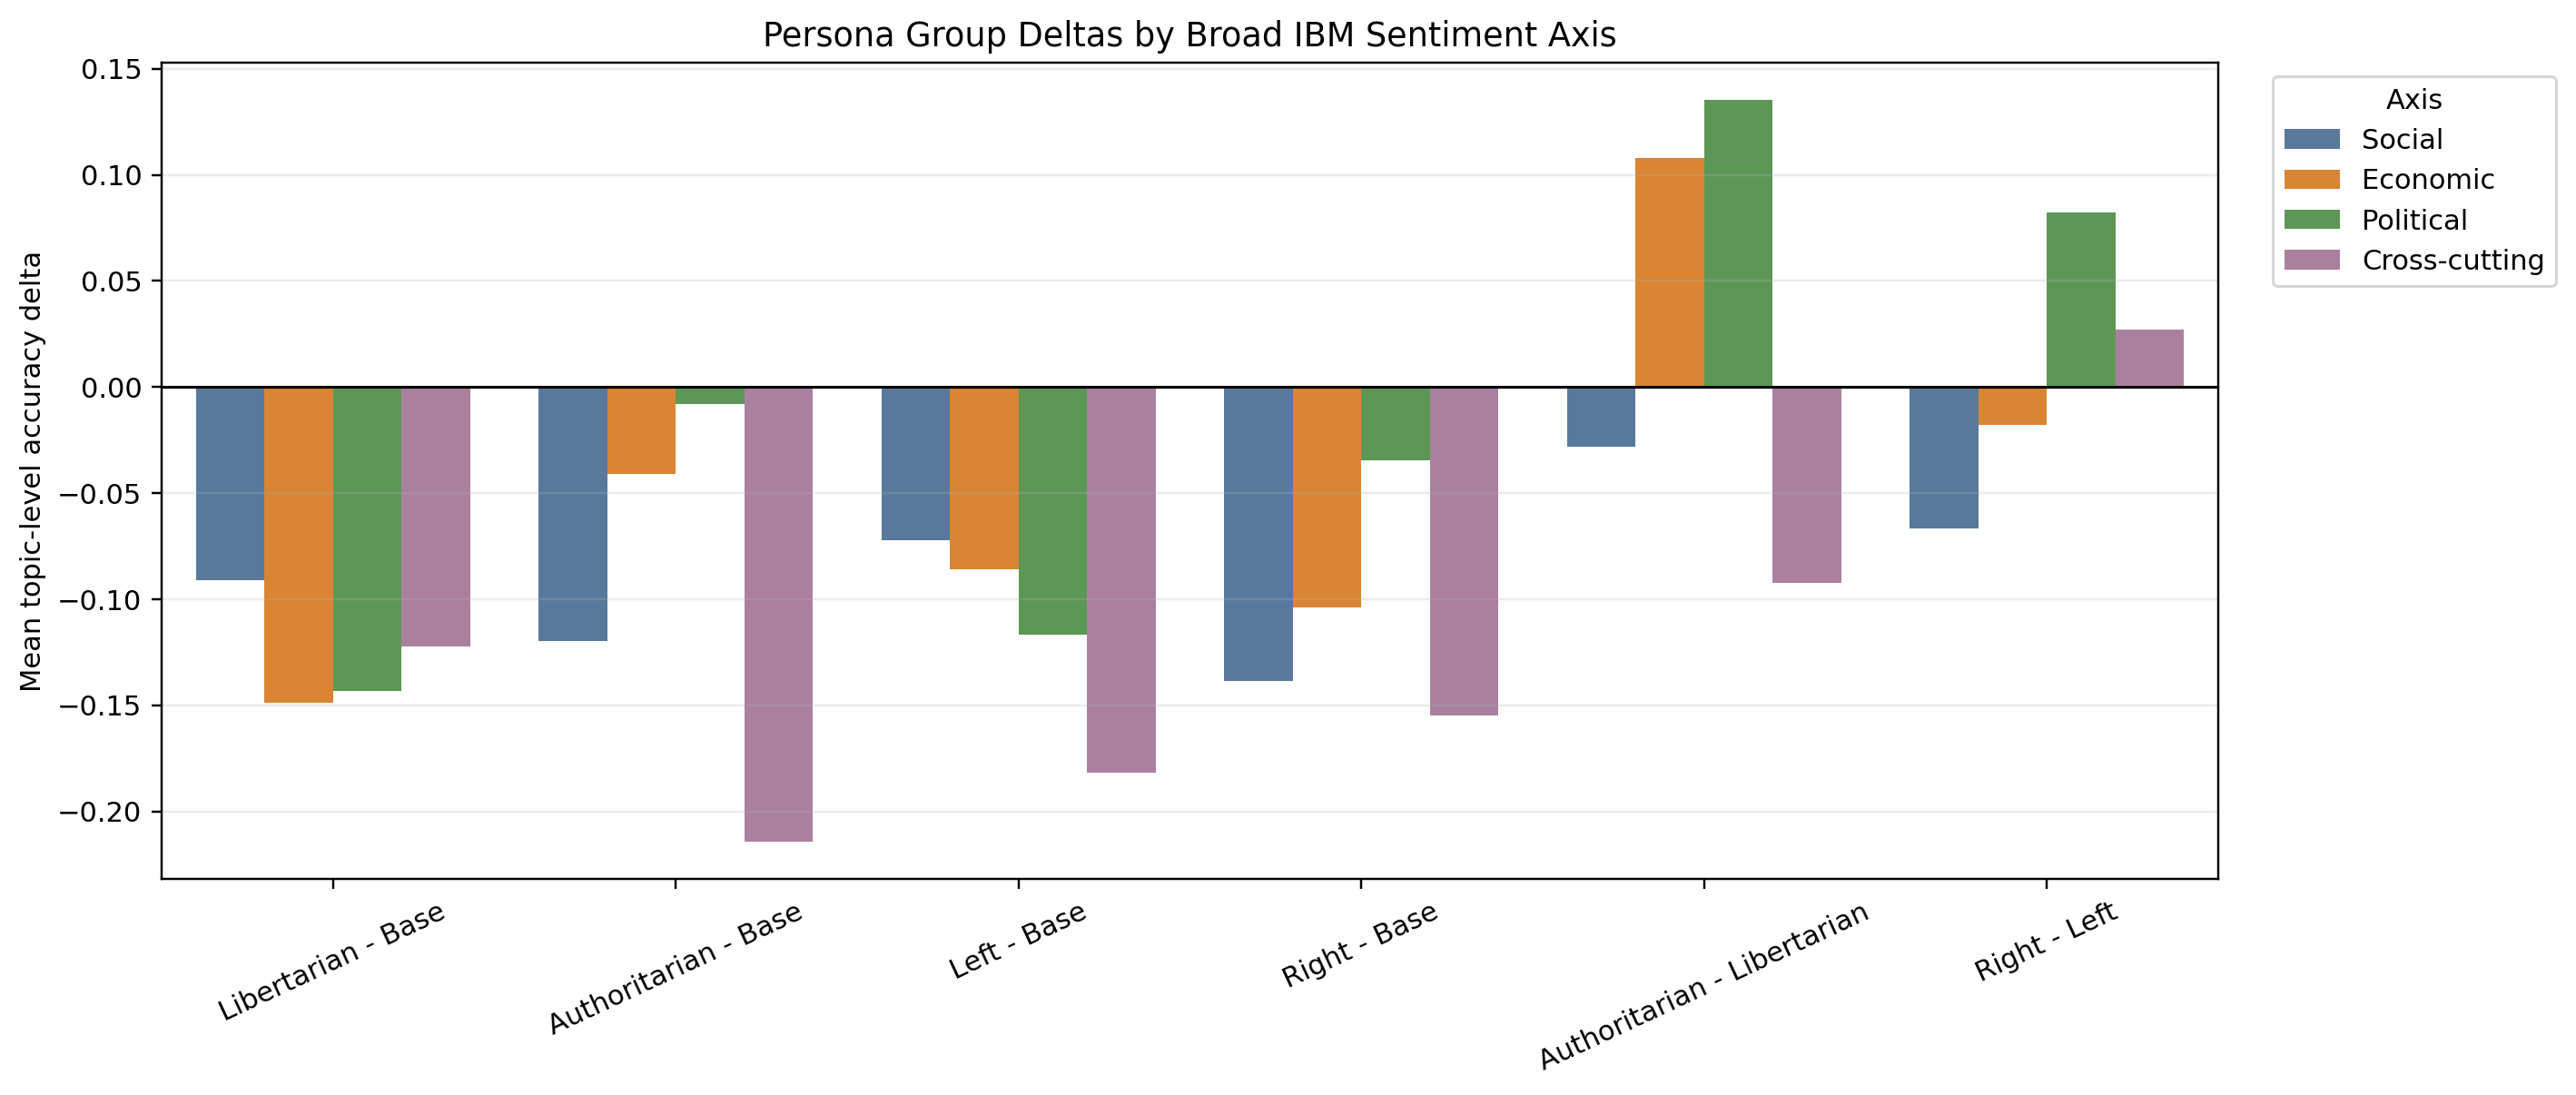

### 4. Factor Sensitivity: Prompt-Space Robustness

`Ideology SD` captures spread between persona/ideology condition means. The `Persona` column captures variation from persona wording/templates. Instruction, context, answer-key type, and residual variance remain important.

**Existing plot: `05_factor_sensitivity_macro_f1.png`**

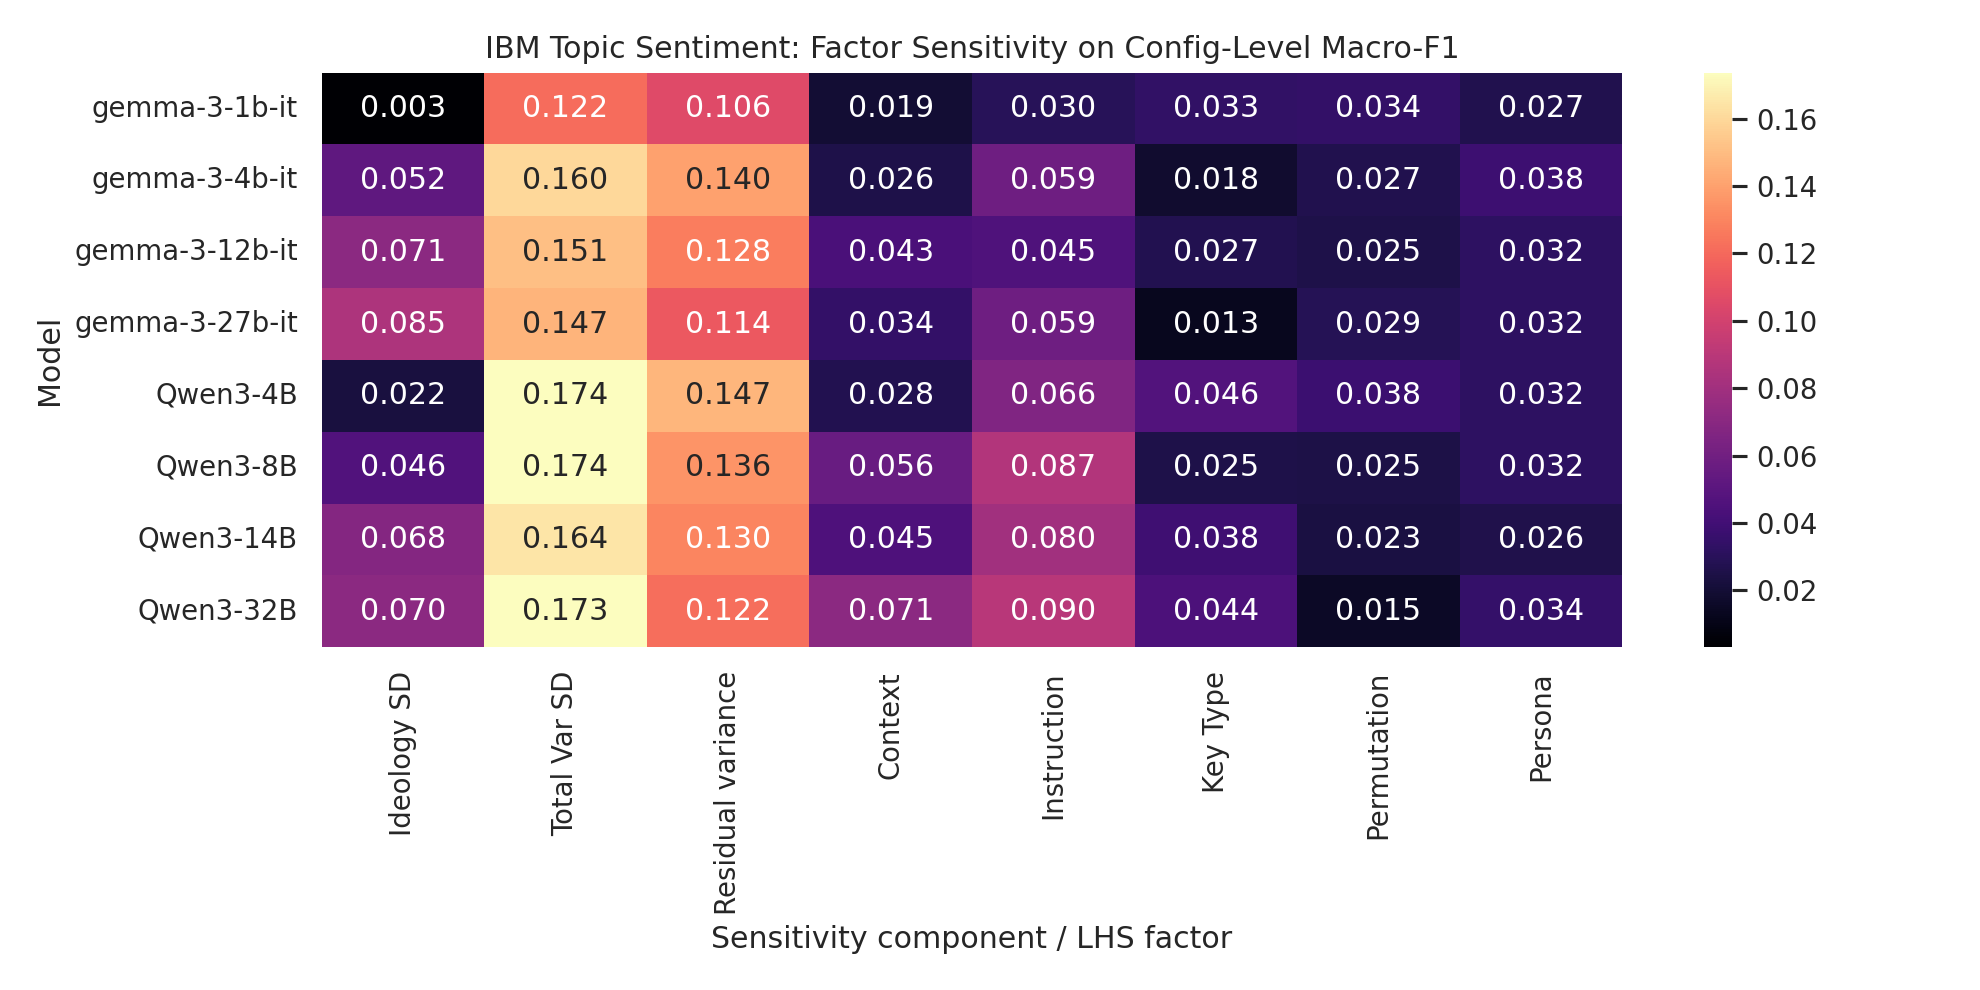

### Appendix Diagnostic: Target-Level Direction Examples

This plot is useful for explaining examples, but it is too dense for the main paper. Use it only if the appendix needs concrete target-level intuition.

**Bias-audit plot: `04_target_auth_lib_right_left_deltas.png`**

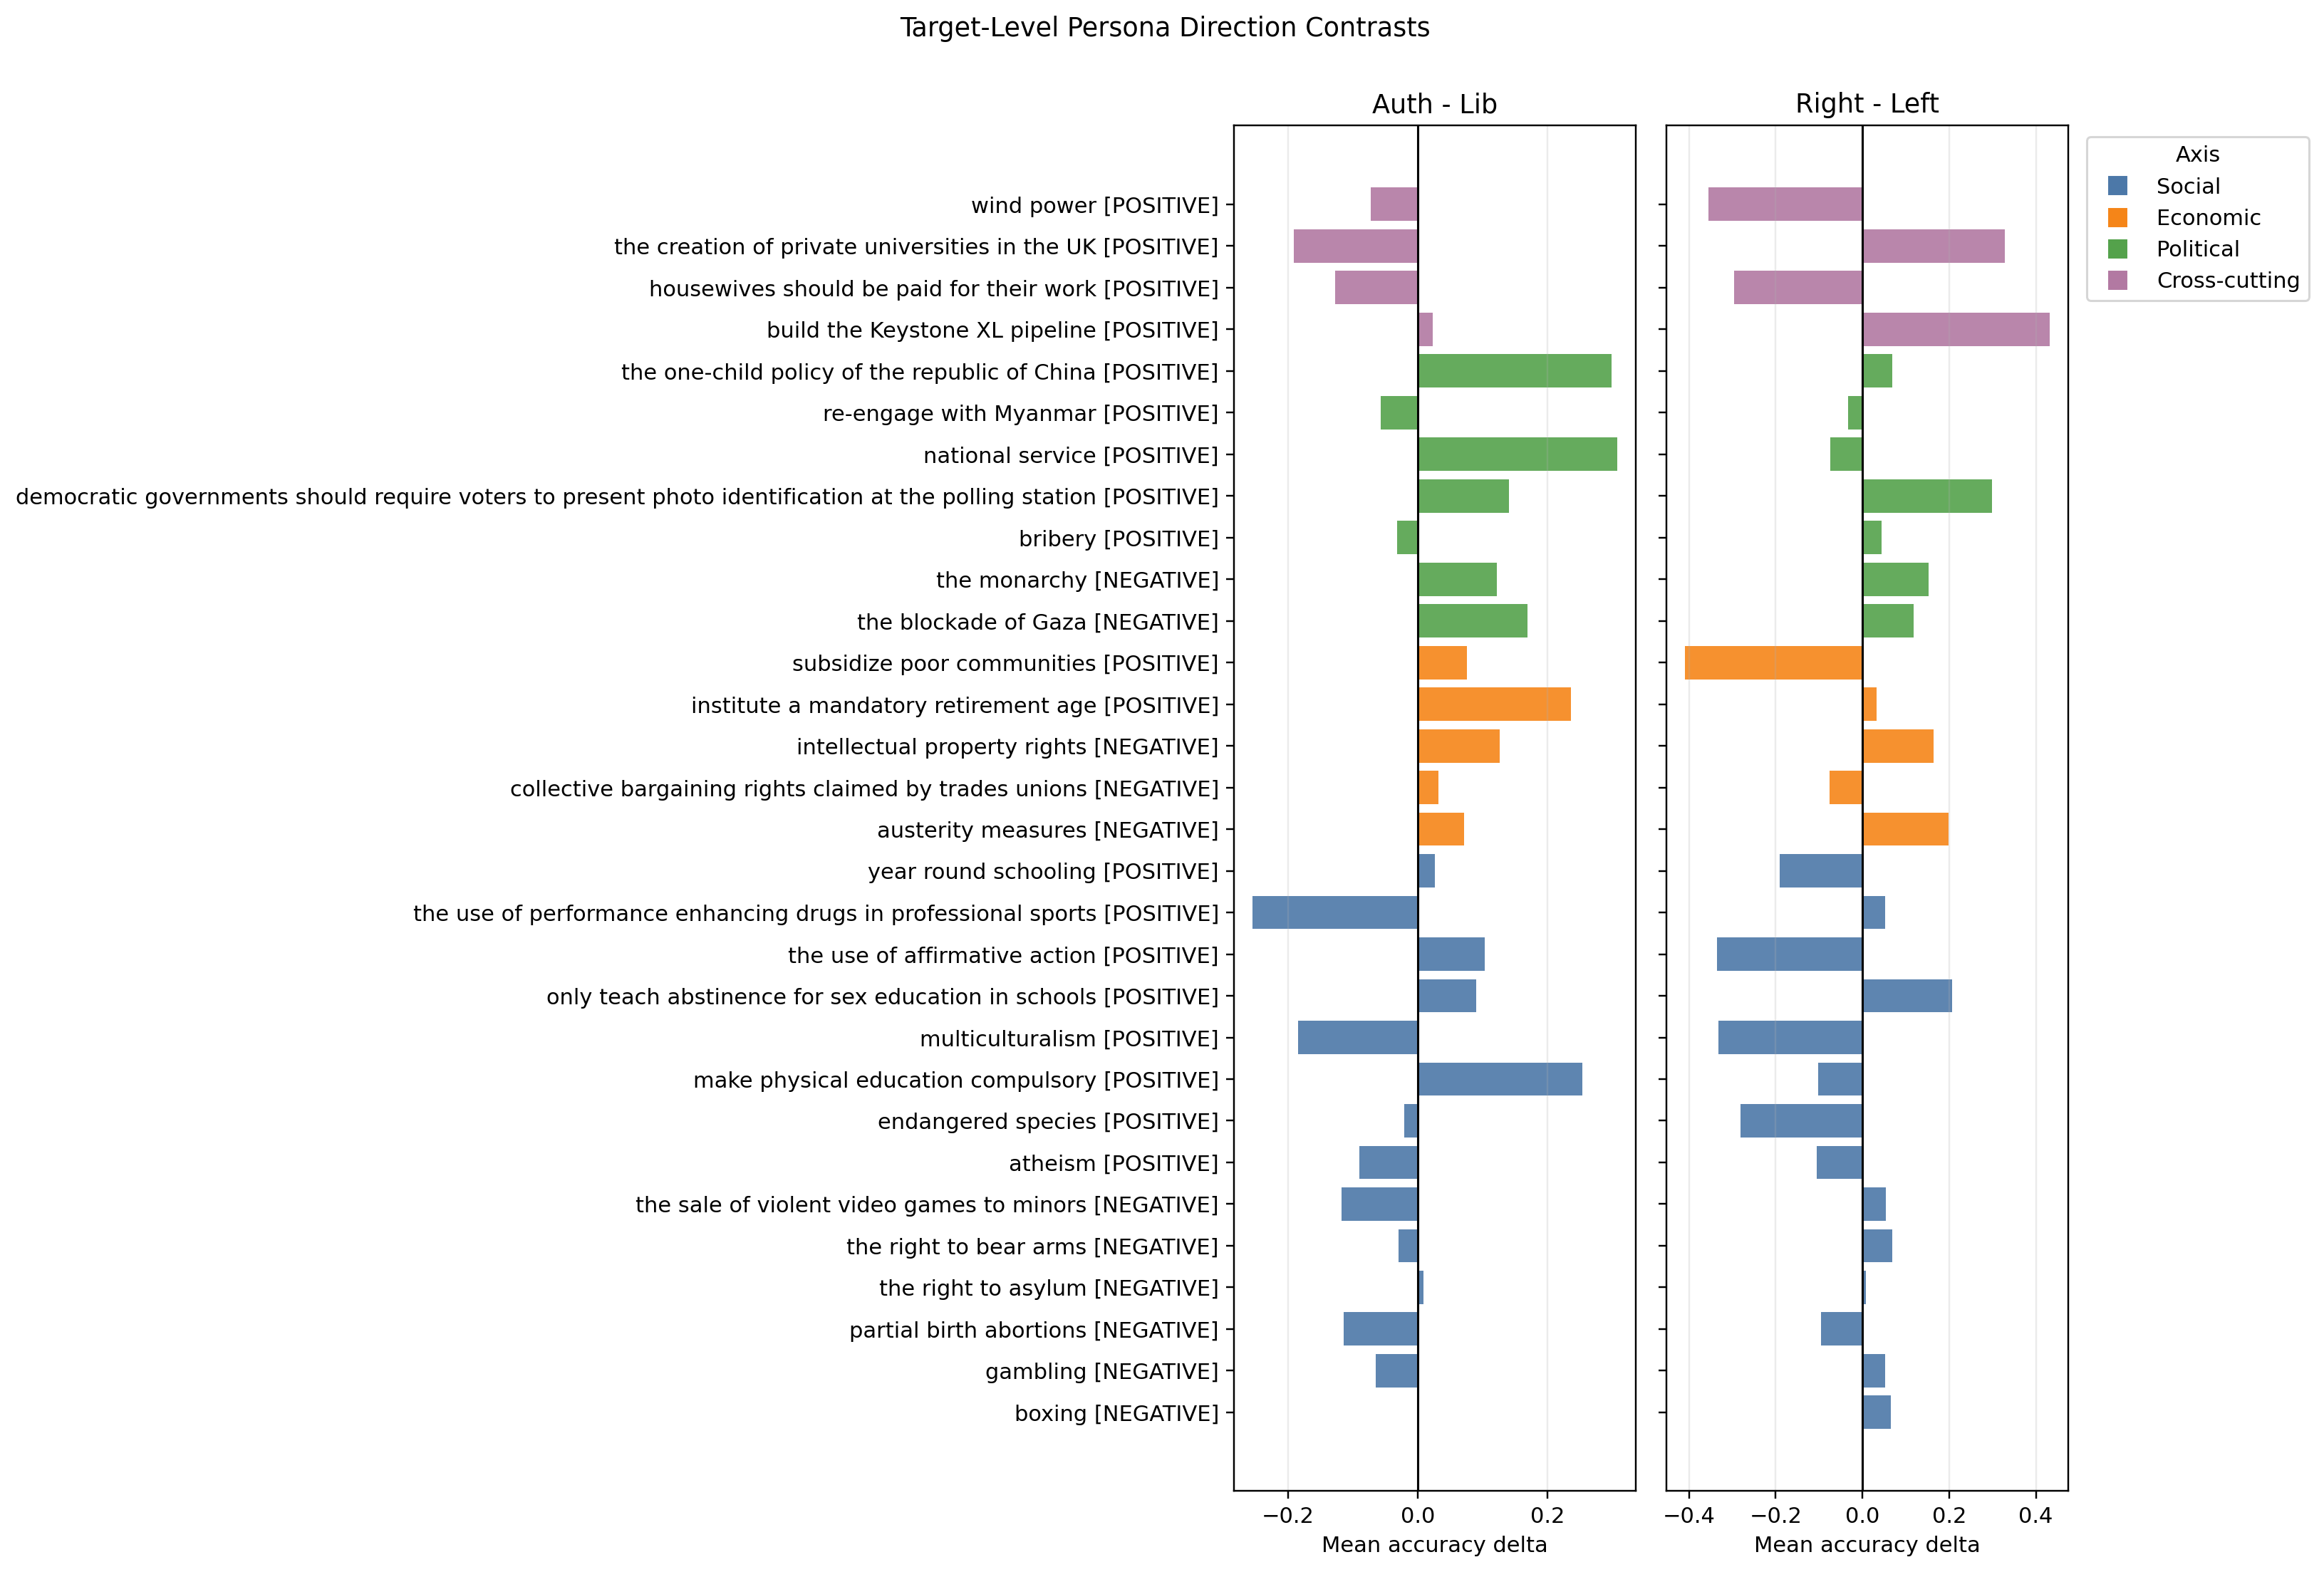

In [17]:
display(Markdown("### 1. Persona Heatmap: Absolute Macro-F1 by Model and Persona"))
display(Markdown(
    "Read this as the direct model/persona performance table. The bright-to-dim pattern is real: base and center are strongest, "
    "while ideological personas generally lower macro-F1."
))
show_source_plot("02_macro_f1_model_persona_heatmap.png")

display(Markdown("### 2. Overall Pairwise Deltas: What Changes Relative to Base/Center?"))
display(Markdown(
    "These bars use topic-level accuracy deltas. Negative bars mean the left-hand condition is worse than the reference. "
    "`Authoritarian - Libertarian` is a comparison between two already-degraded persona families, not a comparison against base."
))
show_bias_plot("01_overall_pairwise_topic_deltas.png")

display(Markdown("### 3. Axis Pairwise Deltas: Where Does the Relative Direction Come From?"))
display(Markdown(
    "Political and economic topics push `Authoritarian - Libertarian` upward, while Social and Cross-cutting topics dampen it. "
    "Support is uneven: Social has 14 topics, Political 7, Economic 5, Cross-cutting 4."
))
show_bias_plot("02_axis_pairwise_topic_deltas.png")

display(Markdown("### 4. Factor Sensitivity: Prompt-Space Robustness"))
display(Markdown(
    "`Ideology SD` captures spread between persona/ideology condition means. The `Persona` column captures variation from persona wording/templates. "
    "Instruction, context, answer-key type, and residual variance remain important."
))
show_source_plot("05_factor_sensitivity_macro_f1.png")

display(Markdown("### Appendix Diagnostic: Target-Level Direction Examples"))
display(Markdown(
    "This plot is useful for explaining examples, but it is too dense for the main paper. Use it only if the appendix needs concrete target-level intuition."
))
show_bias_plot("04_target_auth_lib_right_left_deltas.png")

## Paper-Level Starting Point

These are the result objects already used in the paper-level story: overall macro-F1 by model, model/persona heatmap, and factor sensitivity. This notebook does not reinterpret the full prompt-factor design. It only asks whether the persona story implied by those plots is stable enough to state.

### Overall model performance

,model,n,accuracy,balanced_accuracy,macro_f1,mcc,positive_pred_rate,positive_gold_rate
6,Qwen3-14B,54000,0.583759,0.605796,0.581151,0.205149,0.445574,0.633333
7,Qwen3-32B,54000,0.585130,0.597192,0.579665,0.187484,0.480685,0.633333
5,Qwen3-8B,54000,0.590370,0.588421,0.579017,0.170765,0.530889,0.633333
4,Qwen3-4B,54000,0.579630,0.588735,0.573188,0.171081,0.489519,0.633333
2,gemma-3-12b-it,54000,0.562500,0.590586,0.561306,0.176959,0.418833,0.633333
3,gemma-3-27b-it,54000,0.550000,0.600409,0.549623,0.204621,0.337741,0.633333
1,gemma-3-4b-it,54000,0.532815,0.572616,0.532809,0.144949,0.370111,0.633333
0,gemma-3-1b-it,54000,0.523556,0.519522,0.512033,0.037660,0.520333,0.633333


### Model/persona performance

,model,ideology,n,accuracy,balanced_accuracy,macro_f1,mcc,positive_pred_rate,positive_gold_rate
39,Qwen3-14B,authoritarian_left,9000,0.549889,0.564522,0.545731,0.124725,0.462333,0.633333
40,Qwen3-14B,authoritarian_right,9000,0.555111,0.595502,0.555087,0.190227,0.374000,0.633333
36,Qwen3-14B,base,9000,0.682222,0.693812,0.675724,0.373638,0.508222,0.633333
41,Qwen3-14B,centrism,9000,0.655778,0.669171,0.650024,0.326107,0.494889,0.633333
37,Qwen3-14B,libertarian_left,9000,0.547333,0.554274,0.540519,0.104646,0.488444,0.633333
38,Qwen3-14B,libertarian_right,9000,0.512222,0.557496,0.512005,0.116526,0.345556,0.633333
45,Qwen3-32B,authoritarian_left,9000,0.564222,0.559825,0.551908,0.115560,0.532444,0.633333
46,Qwen3-32B,authoritarian_right,9000,0.576667,0.597400,0.573832,0.188762,0.448222,0.633333
42,Qwen3-32B,base,9000,0.685667,0.689003,0.676173,0.365369,0.537889,0.633333
47,Qwen3-32B,centrism,9000,0.659222,0.659896,0.648653,0.309209,0.540111,0.633333


**Existing plot: `01_macro_f1_by_model.png`**

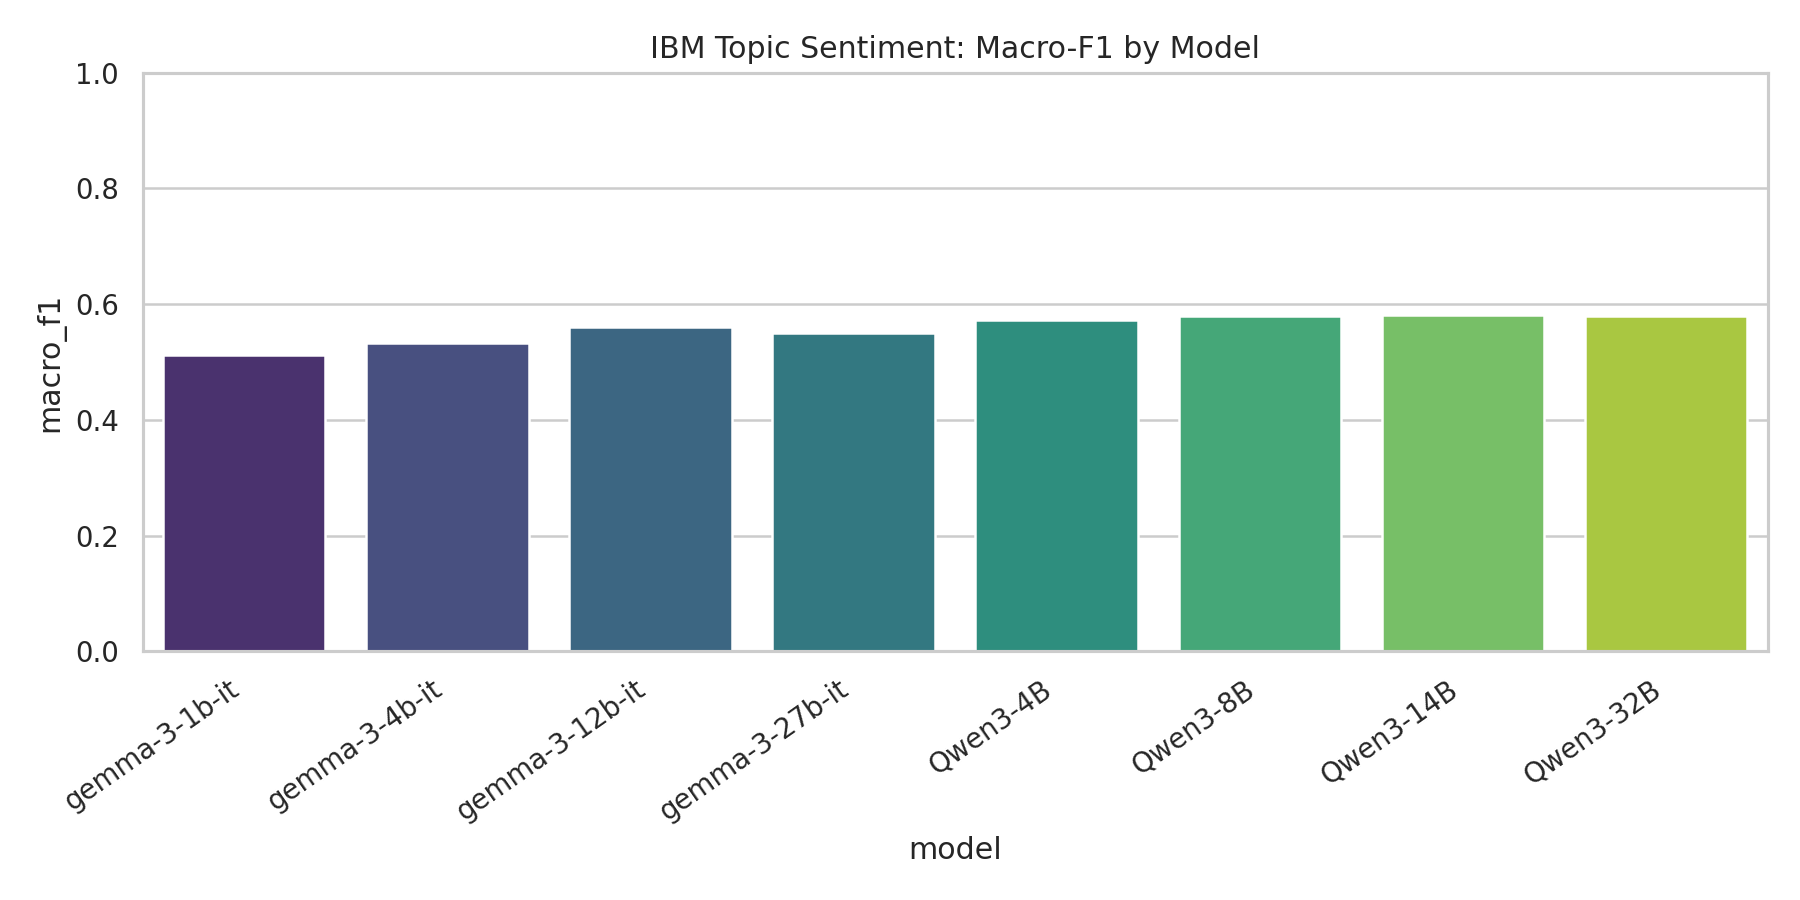

**Existing plot: `02_macro_f1_model_persona_heatmap.png`**

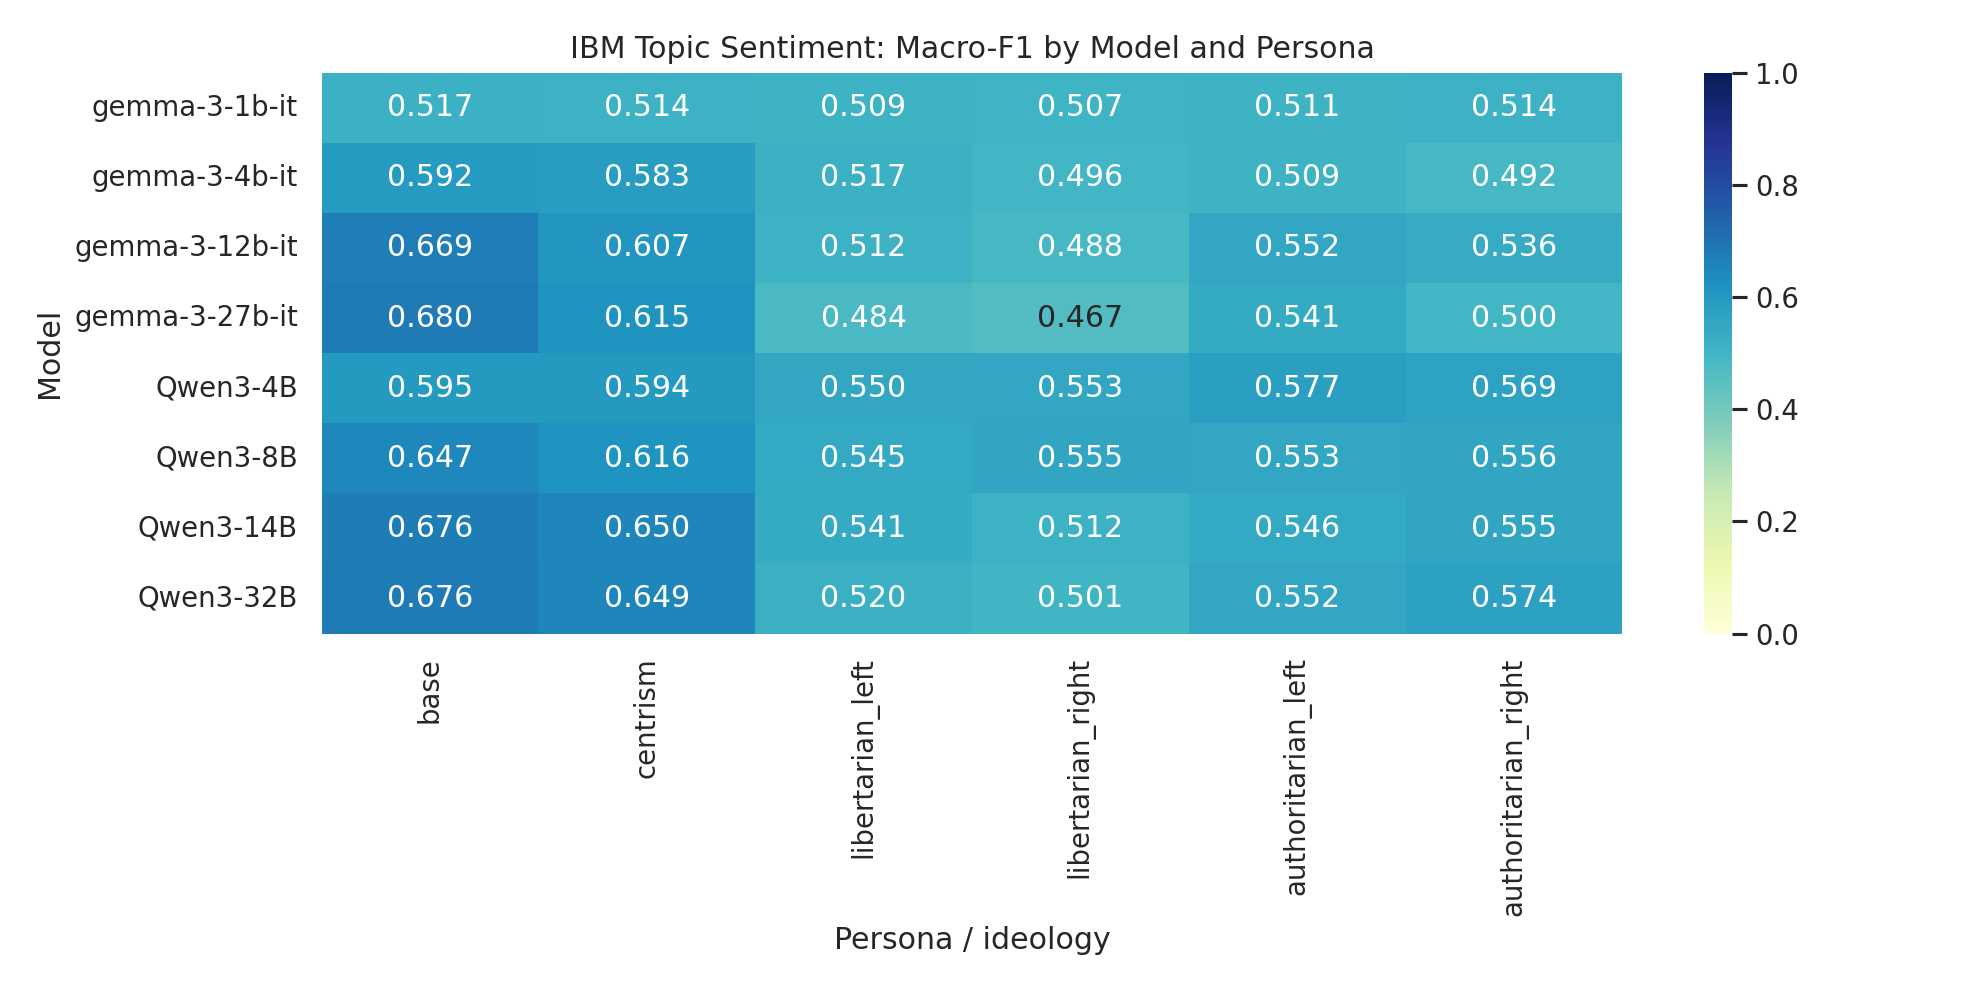

**Existing plot: `05_factor_sensitivity_macro_f1.png`**

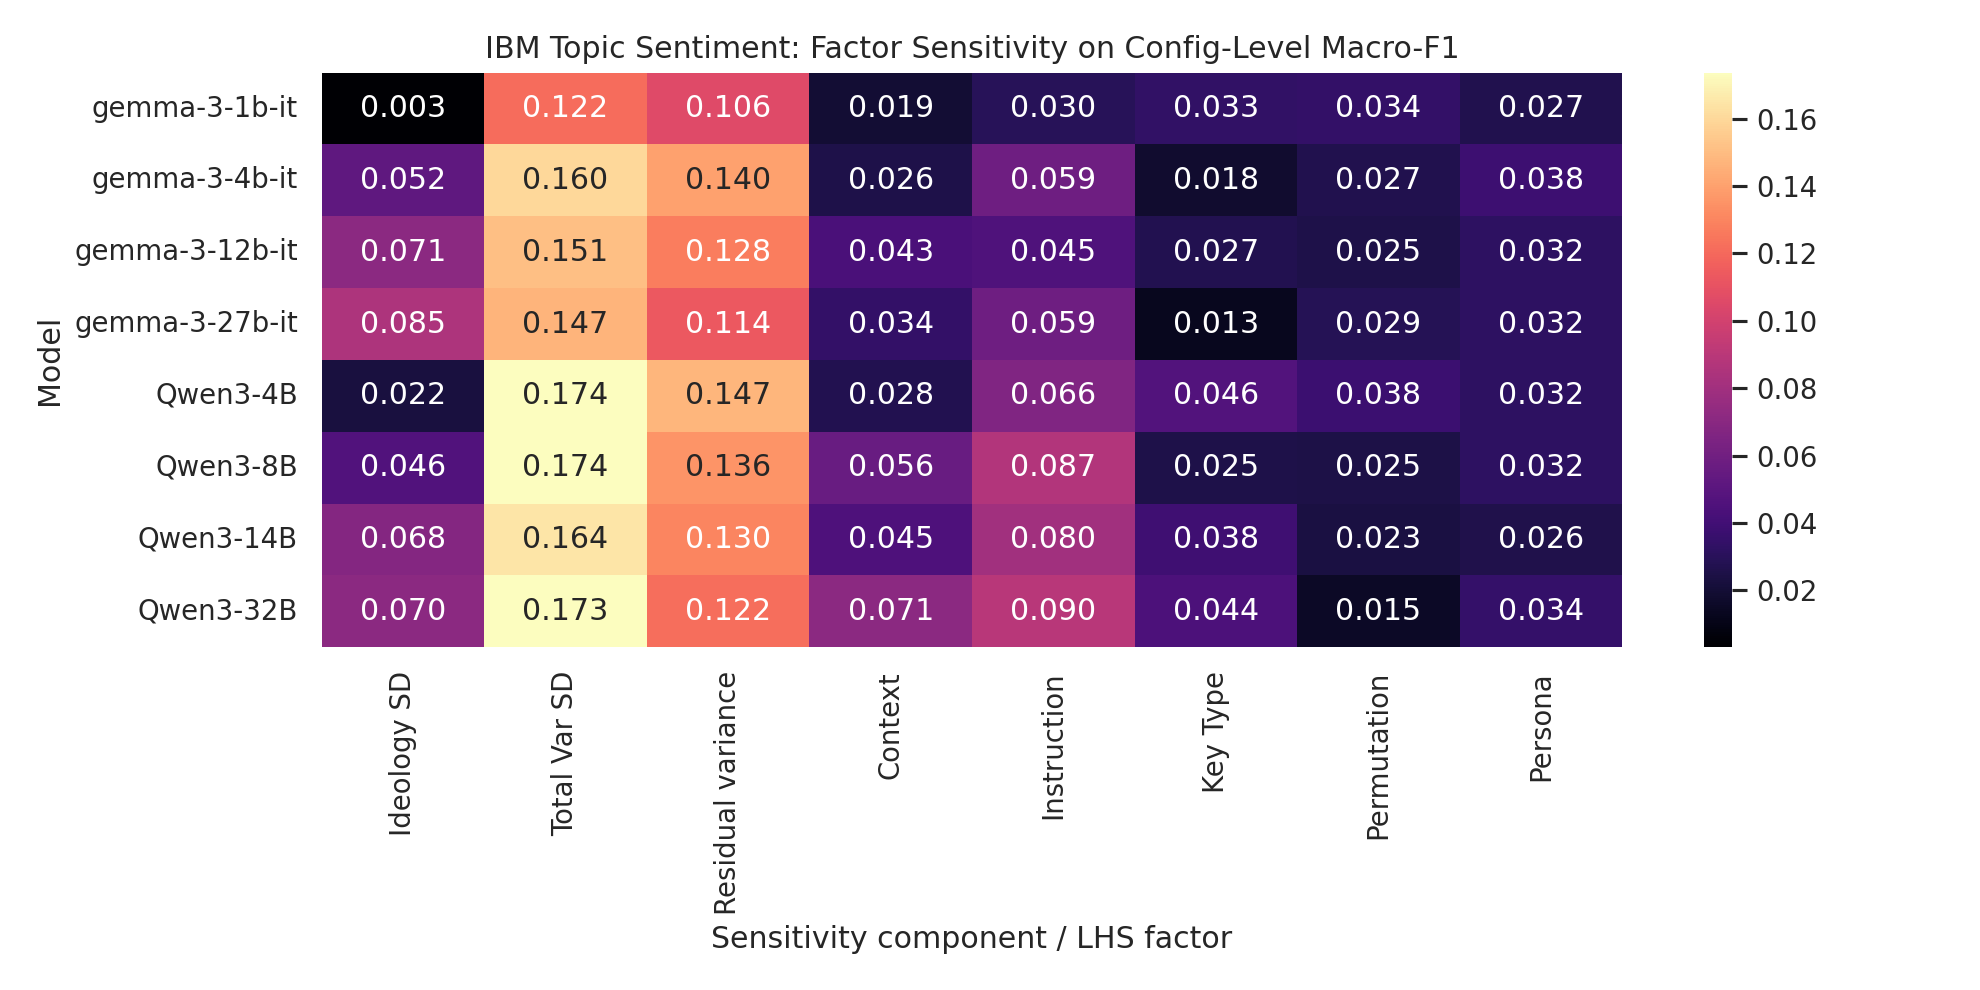

In [18]:
display(Markdown("### Overall model performance"))
display(summary_model.sort_values("macro_f1", ascending=False)[[
    "model", "n", "accuracy", "balanced_accuracy", "macro_f1", "mcc",
    "positive_pred_rate", "positive_gold_rate",
]])

display(Markdown("### Model/persona performance"))
display(summary_ideology.sort_values(["model", "ideology"])[[
    "model", "ideology", "n", "accuracy", "balanced_accuracy", "macro_f1",
    "mcc", "positive_pred_rate", "positive_gold_rate",
]].head(60))

show_source_plot("01_macro_f1_by_model.png")
show_source_plot("02_macro_f1_model_persona_heatmap.png")
show_source_plot("05_factor_sensitivity_macro_f1.png")

## Operationalizing Persona Comparisons

The paper language can become ambiguous because "liberal", "left", and "libertarian" are not identical. Here they are separated:

- `Libertarian`: mean of `libertarian_left` and `libertarian_right`.
- `Authoritarian`: mean of `authoritarian_left` and `authoritarian_right`.
- `Left`: mean of `libertarian_left` and `authoritarian_left`.
- `Right`: mean of `libertarian_right` and `authoritarian_right`.
- `Base` and `Center`: uncollapsed reference conditions.

The conservative statistical unit is the topic. For each comparison, we first average over models within each topic, then test whether the topic-level mean delta differs from zero. Because there are only 30 topics, p-values are interpreted as guardrails, not proof. The notebook also reports the share of models for which the delta has the same sign.

In [19]:
PERSONA_GROUPS = {
    "Base": ["base"],
    "Center": ["centrism"],
    "Libertarian": ["libertarian_left", "libertarian_right"],
    "Authoritarian": ["authoritarian_left", "authoritarian_right"],
    "Left": ["libertarian_left", "authoritarian_left"],
    "Right": ["libertarian_right", "authoritarian_right"],
}

COMPARISONS = [
    ("Center", "Base"),
    ("Libertarian", "Base"),
    ("Authoritarian", "Base"),
    ("Left", "Base"),
    ("Right", "Base"),
    ("Libertarian", "Center"),
    ("Authoritarian", "Center"),
    ("Left", "Center"),
    ("Right", "Center"),
    ("Authoritarian", "Libertarian"),
    ("Right", "Left"),
]

INDIVIDUAL_COMPARISONS = [
    ("centrism", "base"),
    ("libertarian_left", "base"),
    ("libertarian_right", "base"),
    ("authoritarian_left", "base"),
    ("authoritarian_right", "base"),
    ("libertarian_left", "centrism"),
    ("libertarian_right", "centrism"),
    ("authoritarian_left", "centrism"),
    ("authoritarian_right", "centrism"),
    ("authoritarian_left", "libertarian_left"),
    ("authoritarian_right", "libertarian_right"),
]


def make_group_scores(df: pd.DataFrame) -> pd.DataFrame:
    id_cols = [
        "model", "item_index", "target", "axis", "domain",
        "keyword_primary_label", "gold_label",
    ]
    rows = []
    for group, ideologies in PERSONA_GROUPS.items():
        sub = df[df["ideology"].astype(str).isin(ideologies)].copy()
        grouped = (
            sub.groupby(id_cols, observed=True)["item_accuracy"]
            .mean()
            .reset_index()
        )
        grouped["persona_group"] = group
        rows.append(grouped)
    return pd.concat(rows, ignore_index=True)


group_scores = make_group_scores(item_acc)
wide_group = (
    group_scores.pivot_table(
        index=["model", "item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label"],
        columns="persona_group",
        values="item_accuracy",
        aggfunc="mean",
    )
    .reset_index()
)
wide_group.columns.name = None

wide_individual = (
    item_acc.pivot_table(
        index=["model", "item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label"],
        columns="ideology",
        values="item_accuracy",
        aggfunc="mean",
    )
    .reset_index()
)
wide_individual.columns.name = None

write_table(group_scores, "persona_group_topic_model_scores.csv")
write_table(wide_group, "persona_group_topic_model_scores_wide.csv")
print(f"group_scores rows={len(group_scores):,}; wide rows={len(wide_group):,}")

group_scores rows=1,440; wide rows=240


In [20]:
def bootstrap_ci(values: np.ndarray, n_boot: int = 10000, seed: int = 17) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    means = values[idx].mean(axis=1)
    return float(np.quantile(means, 0.025)), float(np.quantile(means, 0.975))


def signflip_p_value(values: np.ndarray, n_draws: int = 20000, seed: int = 23) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan
    observed = abs(values.mean())
    rng = np.random.default_rng(seed)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_draws, len(values)))
    null_means = np.abs((signs * values).mean(axis=1))
    return float((np.sum(null_means >= observed) + 1) / (n_draws + 1))


def bh_q_values(p_values: pd.Series) -> pd.Series:
    p = pd.to_numeric(p_values, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    if valid.empty:
        return out
    m = len(valid)
    ranks = np.arange(1, m + 1)
    q_sorted = valid.to_numpy() * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)
    out.loc[valid.index] = q_sorted
    return out


def summarize_deltas(delta_df: pd.DataFrame, group_cols: list[str], delta_col: str = "delta") -> pd.DataFrame:
    rows = []
    grouped = [((), delta_df)] if not group_cols else delta_df.groupby(group_cols, observed=True, dropna=False)
    for key, sub in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        values = sub[delta_col].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        ci_low, ci_high = bootstrap_ci(values)
        row = {col: val for col, val in zip(group_cols, key)}
        row.update(
            n_units=int(len(values)),
            mean_delta=float(np.mean(values)) if len(values) else np.nan,
            median_delta=float(np.median(values)) if len(values) else np.nan,
            ci_low=ci_low,
            ci_high=ci_high,
            positive_delta_share=float(np.mean(values > 0)) if len(values) else np.nan,
            negative_delta_share=float(np.mean(values < 0)) if len(values) else np.nan,
            mean_abs_delta=float(np.mean(np.abs(values))) if len(values) else np.nan,
            signflip_p_value=signflip_p_value(values),
        )
        rows.append(row)
    result = pd.DataFrame(rows)
    if "signflip_p_value" in result.columns:
        result["q_value_bh"] = bh_q_values(result["signflip_p_value"])
    return result


def build_comparison_units(wide: pd.DataFrame, comparisons: list[tuple[str, str]], label_type: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    model_topic_rows = []
    topic_rows = []
    id_cols = ["item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label"]
    for left, right in comparisons:
        if left not in wide.columns or right not in wide.columns:
            continue
        tmp = wide[["model"] + id_cols + [left, right]].copy()
        tmp["left"] = left
        tmp["right"] = right
        tmp["contrast"] = f"{left} - {right}"
        tmp["label_type"] = label_type
        tmp["left_accuracy"] = tmp[left]
        tmp["right_accuracy"] = tmp[right]
        tmp["delta"] = tmp[left] - tmp[right]
        model_topic_rows.append(tmp[["label_type", "contrast", "left", "right", "model"] + id_cols + ["left_accuracy", "right_accuracy", "delta"]])

        topic = (
            tmp.groupby(["left", "right", "contrast"] + id_cols, observed=True)
            .agg(
                left_accuracy=("left_accuracy", "mean"),
                right_accuracy=("right_accuracy", "mean"),
                delta=("delta", "mean"),
                n_models=("model", "nunique"),
                models_left_gt_right=("delta", lambda s: int(np.sum(np.asarray(s) > 0))),
                models_right_gt_left=("delta", lambda s: int(np.sum(np.asarray(s) < 0))),
            )
            .reset_index()
        )
        topic["label_type"] = label_type
        topic["left_gt_right_share"] = topic["models_left_gt_right"] / topic["n_models"].replace(0, np.nan)
        topic["right_gt_left_share"] = topic["models_right_gt_left"] / topic["n_models"].replace(0, np.nan)
        topic_rows.append(topic[["label_type", "contrast", "left", "right"] + id_cols + [
            "left_accuracy", "right_accuracy", "delta", "n_models",
            "models_left_gt_right", "models_right_gt_left", "left_gt_right_share", "right_gt_left_share",
        ]])
    return pd.concat(model_topic_rows, ignore_index=True), pd.concat(topic_rows, ignore_index=True)


group_model_topic_deltas, group_topic_deltas = build_comparison_units(wide_group, COMPARISONS, "persona_group")
individual_model_topic_deltas, individual_topic_deltas = build_comparison_units(wide_individual, INDIVIDUAL_COMPARISONS, "individual_persona")

write_table(group_model_topic_deltas, "group_model_topic_pairwise_deltas.csv")
write_table(group_topic_deltas, "group_topic_pairwise_deltas.csv")
write_table(individual_model_topic_deltas, "individual_model_topic_pairwise_deltas.csv")
write_table(individual_topic_deltas, "individual_topic_pairwise_deltas.csv")

print(f"group_topic_deltas rows={len(group_topic_deltas):,}")
print(f"individual_topic_deltas rows={len(individual_topic_deltas):,}")

group_topic_deltas rows=330
individual_topic_deltas rows=330


## Overall Pairwise Tests

The first table uses 30 topic-level units after averaging over models. This is the safest inferential view. The second table uses 240 model-topic units and is more sensitive, but less conservative because model-level observations over the same topic are not fully independent.

### Conservative topic-level group comparisons

,contrast,left,right,n_units,mean_delta,median_delta,ci_low,ci_high,positive_delta_share,negative_delta_share,mean_abs_delta,signflip_p_value,q_value_bh
6,Libertarian - Base,Libertarian,Base,30,-0.117146,-0.107396,-0.157292,-0.077325,0.100000,0.900000,0.134049,0.000050,0.000275
8,Right - Base,Right,Base,30,-0.110743,-0.049167,-0.179180,-0.047159,0.233333,0.766667,0.158854,0.002750,0.005041
4,Left - Base,Left,Base,30,-0.099465,-0.080208,-0.133431,-0.068569,0.100000,0.900000,0.102354,0.000050,0.000275
0,Authoritarian - Base,Authoritarian,Base,30,-0.093063,-0.092604,-0.140889,-0.044180,0.233333,0.766667,0.133729,0.000700,0.001925
7,Libertarian - Center,Libertarian,Center,30,-0.091049,-0.089375,-0.138092,-0.045368,0.366667,0.633333,0.128118,0.000900,0.001980
9,Right - Center,Right,Center,30,-0.084646,-0.005625,-0.155473,-0.018104,0.433333,0.566667,0.153701,0.023649,0.028904
5,Left - Center,Left,Center,30,-0.073368,-0.034062,-0.112820,-0.037736,0.200000,0.800000,0.087063,0.000250,0.000917
1,Authoritarian - Center,Authoritarian,Center,30,-0.066965,-0.053646,-0.116737,-0.016812,0.300000,0.700000,0.118979,0.014249,0.019593
3,Center - Base,Center,Base,30,-0.026097,-0.028333,-0.045029,-0.008124,0.333333,0.666667,0.047542,0.011799,0.018542
10,Right - Left,Right,Left,30,-0.011278,0.038958,-0.086355,0.062728,0.566667,0.433333,0.167875,0.774911,0.774911


### Individual persona comparisons against base/center

,contrast,left,right,n_units,mean_delta,median_delta,ci_low,ci_high,positive_delta_share,negative_delta_share,mean_abs_delta,signflip_p_value,q_value_bh
9,libertarian_right - base,libertarian_right,base,30,-0.124153,-0.104167,-0.189779,-0.061653,0.266667,0.733333,0.168125,0.000900,0.003300
7,libertarian_left - base,libertarian_left,base,30,-0.110139,-0.094375,-0.148486,-0.072054,0.133333,0.866667,0.122694,0.000050,0.000550
10,libertarian_right - centrism,libertarian_right,centrism,30,-0.098056,-0.069583,-0.167739,-0.032083,0.433333,0.566667,0.167333,0.009300,0.018542
3,authoritarian_right - base,authoritarian_right,base,30,-0.097333,-0.068542,-0.175821,-0.021194,0.266667,0.733333,0.183083,0.020549,0.028255
0,authoritarian_left - base,authoritarian_left,base,30,-0.088792,-0.070208,-0.133528,-0.047056,0.233333,0.766667,0.115014,0.000150,0.000825
8,libertarian_left - centrism,libertarian_left,centrism,30,-0.084042,-0.049792,-0.130022,-0.040013,0.333333,0.666667,0.114125,0.001300,0.003575
4,authoritarian_right - centrism,authoritarian_right,centrism,30,-0.071236,-0.041042,-0.151626,0.006074,0.433333,0.566667,0.177819,0.089496,0.109383
1,authoritarian_left - centrism,authoritarian_left,centrism,30,-0.062694,-0.042917,-0.111223,-0.019333,0.333333,0.666667,0.100056,0.010899,0.018542
6,centrism - base,centrism,base,30,-0.026097,-0.028333,-0.045029,-0.008124,0.333333,0.666667,0.047542,0.011799,0.018542
2,authoritarian_left - libertarian_left,authoritarian_left,libertarian_left,30,0.021347,0.015625,-0.029224,0.073532,0.566667,0.433333,0.115653,0.428579,0.428579


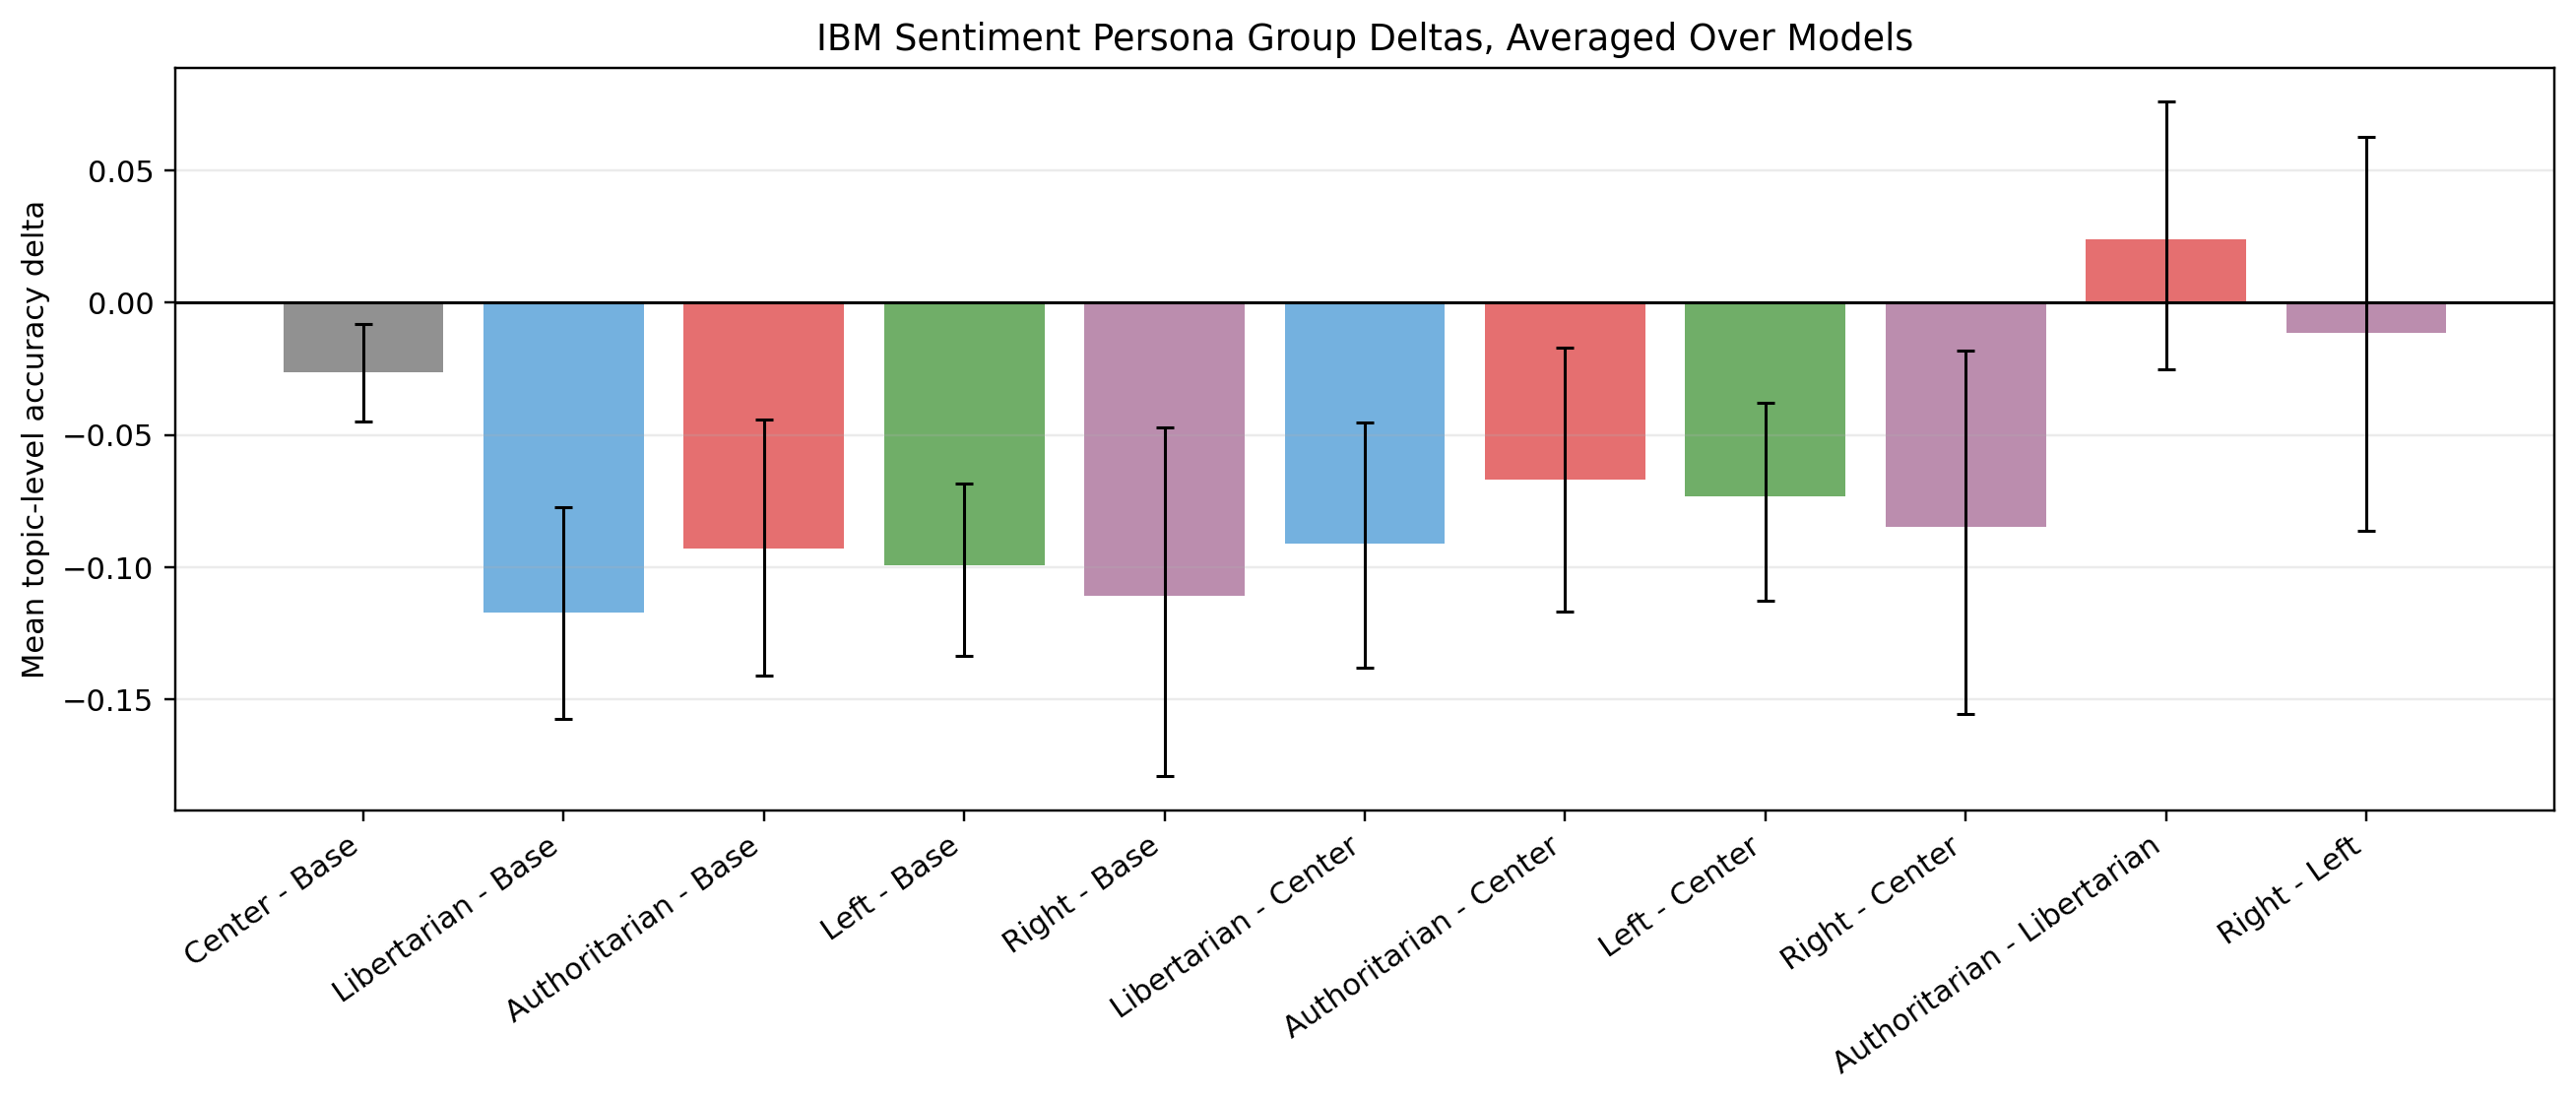

In [21]:
overall_topic = summarize_deltas(group_topic_deltas, ["contrast", "left", "right"])
overall_model_topic = summarize_deltas(group_model_topic_deltas, ["contrast", "left", "right"])
overall_individual_topic = summarize_deltas(individual_topic_deltas, ["contrast", "left", "right"])

write_table(overall_topic, "overall_group_pairwise_topic_tests.csv")
write_table(overall_model_topic, "overall_group_pairwise_model_topic_tests_descriptive.csv")
write_table(overall_individual_topic, "overall_individual_persona_pairwise_topic_tests.csv")

display(Markdown("### Conservative topic-level group comparisons"))
show_table(overall_topic.sort_values("mean_delta"), n=30)

display(Markdown("### Individual persona comparisons against base/center"))
show_table(overall_individual_topic.sort_values("mean_delta"), n=30)

plot_df = overall_topic.copy()
plot_df["contrast"] = pd.Categorical(plot_df["contrast"], categories=[f"{l} - {r}" for l, r in COMPARISONS], ordered=True)
plot_df = plot_df.sort_values("contrast")

fig, ax = plt.subplots(figsize=(12, 5.2))
x = np.arange(len(plot_df))
colors = [GROUP_COLORS.get(left, "#777777") for left in plot_df["left"]]
ax.bar(x, plot_df["mean_delta"], color=colors, alpha=0.86)
ax.errorbar(
    x,
    plot_df["mean_delta"],
    yerr=[
        plot_df["mean_delta"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["mean_delta"],
    ],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["contrast"], rotation=35, ha="right")
ax.set_ylabel("Mean topic-level accuracy delta")
ax.set_title("IBM Sentiment Persona Group Deltas, Averaged Over Models")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
out_path = PLOTS_DIR / "01_overall_pairwise_topic_deltas.png"
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(out_path)))

## Axis-Level Comparisons

This is the broad grouping that is safest to discuss in the paper without introducing the full target taxonomy. Support is uneven: Social has the most topics, while Cross-cutting and Economic have only a few. Use the support counts when interpreting any apparent axis difference.

,axis,gold_label,n_topics
0,Cross-cutting,POSITIVE,4
1,Economic,NEGATIVE,3
2,Economic,POSITIVE,2
3,Political,NEGATIVE,2
4,Political,POSITIVE,5
5,Social,NEGATIVE,6
6,Social,POSITIVE,8


,contrast,left,right,axis,n_units,mean_delta,median_delta,ci_low,ci_high,positive_delta_share,negative_delta_share,mean_abs_delta,signflip_p_value,q_value_bh
3,Authoritarian - Base,Authoritarian,Base,Social,14,-0.119554,-0.110313,-0.189821,-0.054182,0.071429,0.928571,0.144345,0.003800,0.083596
1,Authoritarian - Base,Authoritarian,Base,Economic,5,-0.040833,-0.071042,-0.139542,0.056583,0.400000,0.600000,0.110250,0.559822,0.685938
2,Authoritarian - Base,Authoritarian,Base,Political,7,-0.008036,0.003125,-0.090208,0.065625,0.571429,0.428571,0.083155,0.892405,0.913159
0,Authoritarian - Base,Authoritarian,Base,Cross-cutting,4,-0.214427,-0.245521,-0.257292,-0.140469,0.000000,1.000000,0.214427,0.125794,0.224389
7,Authoritarian - Center,Authoritarian,Center,Social,14,-0.077381,-0.071354,-0.146193,-0.016114,0.285714,0.714286,0.107113,0.033948,0.186716
5,Authoritarian - Center,Authoritarian,Center,Economic,5,-0.021583,-0.023125,-0.130833,0.078125,0.400000,0.600000,0.104333,0.809860,0.890845
6,Authoritarian - Center,Authoritarian,Center,Political,7,0.004345,-0.020000,-0.098575,0.105625,0.428571,0.571429,0.100000,0.984551,0.984551
4,Authoritarian - Center,Authoritarian,Center,Cross-cutting,4,-0.212031,-0.236354,-0.253125,-0.146615,0.000000,1.000000,0.212031,0.125794,0.224389
11,Authoritarian - Libertarian,Authoritarian,Libertarian,Social,14,-0.028289,-0.025625,-0.090536,0.040166,0.428571,0.571429,0.097247,0.424579,0.584704
9,Authoritarian - Libertarian,Authoritarian,Libertarian,Economic,5,0.108083,0.075417,0.056500,0.172833,1.000000,0.000000,0.108083,0.063147,0.213728


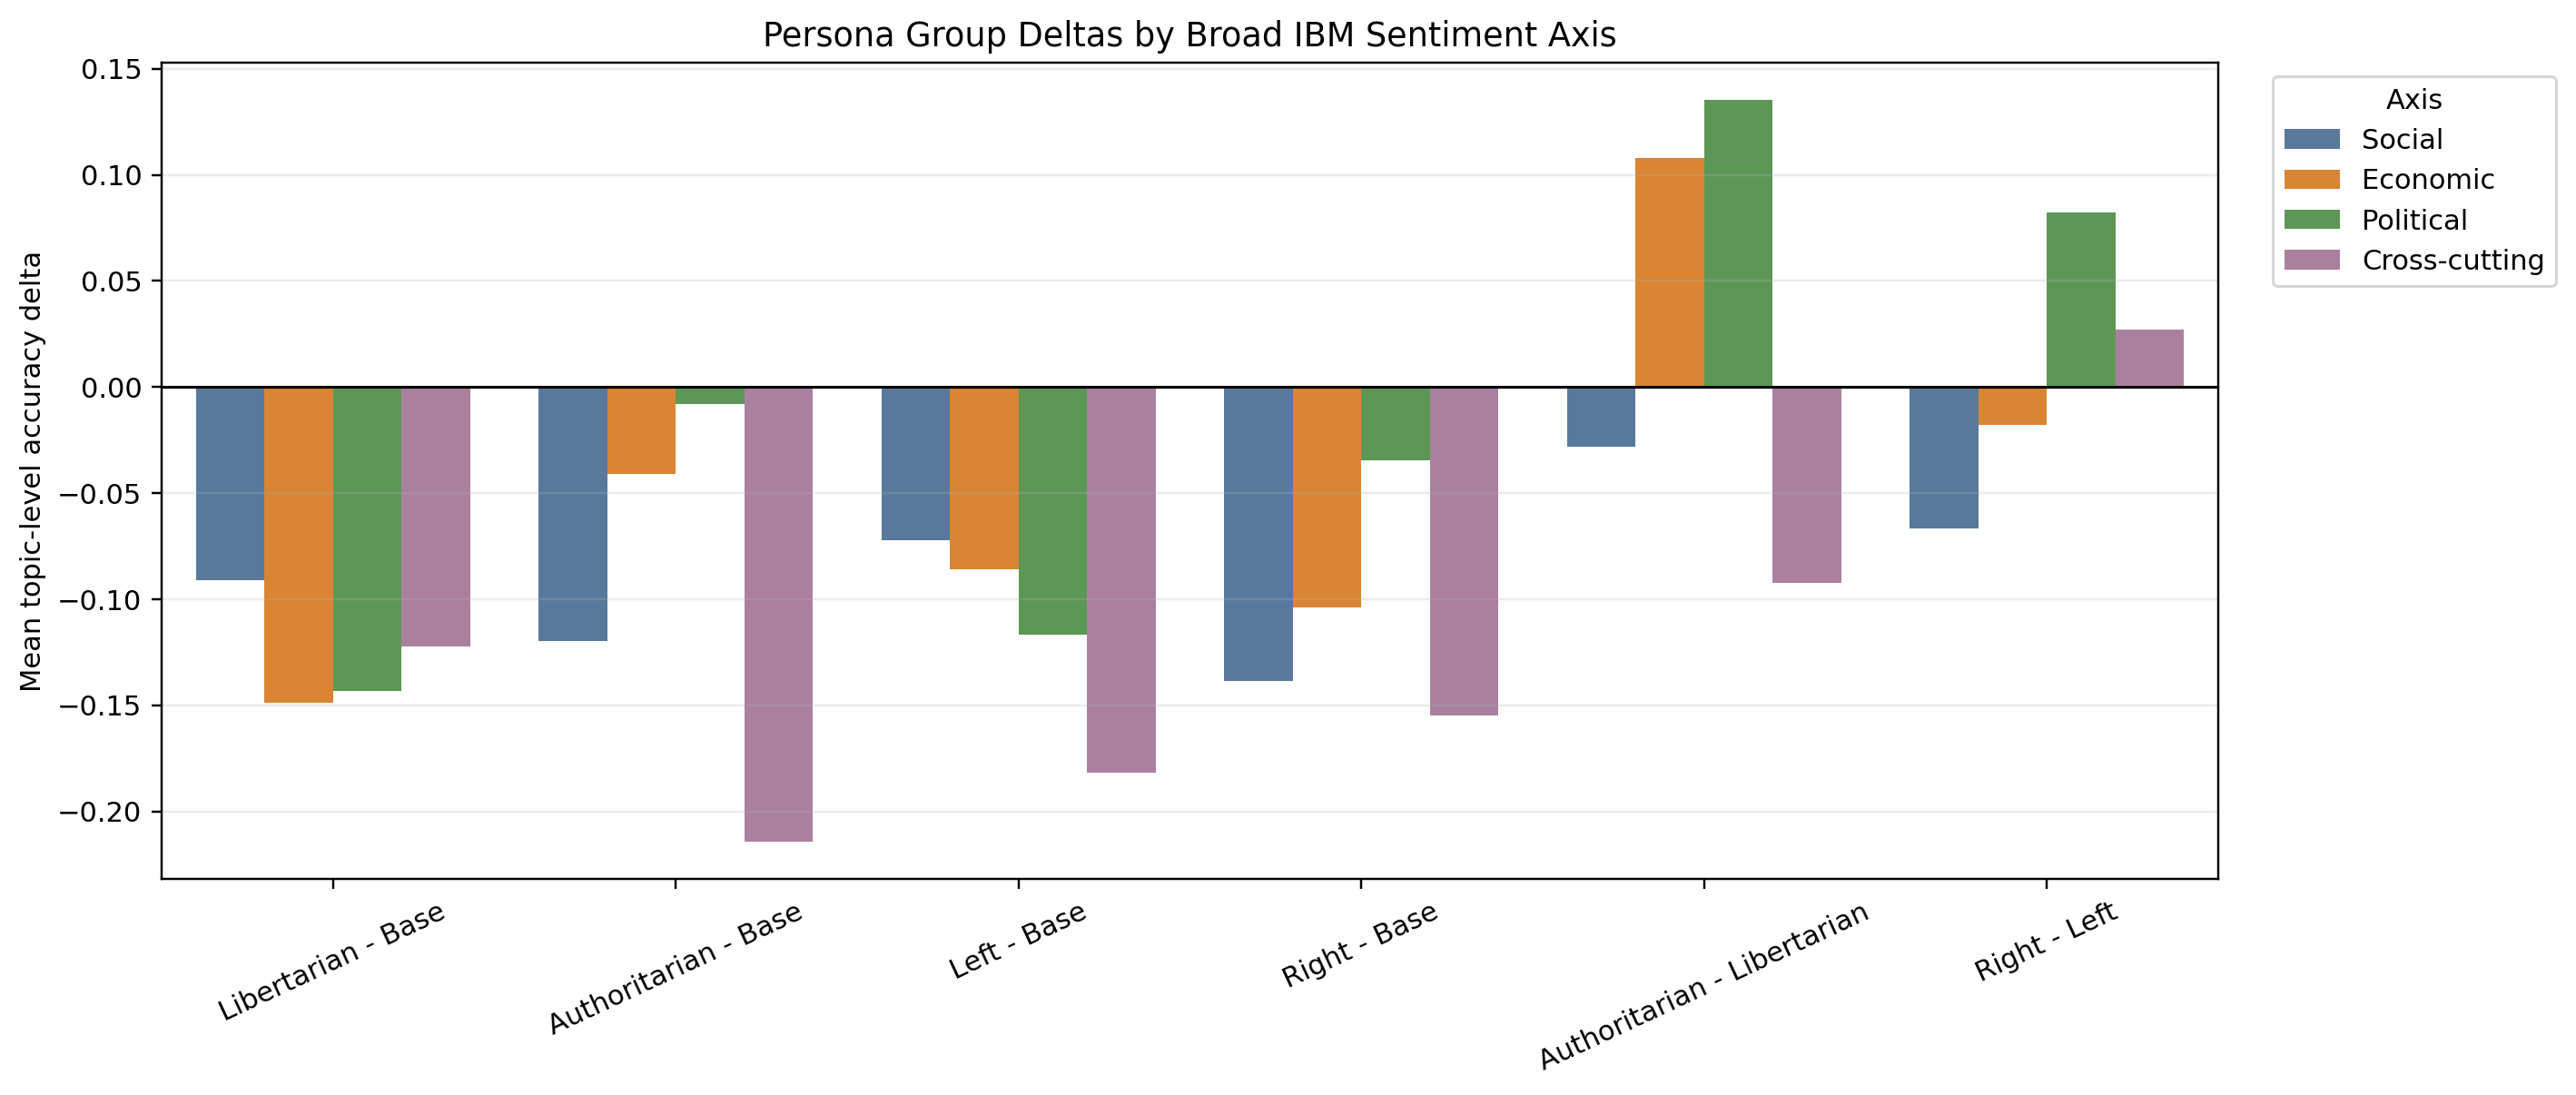

In [22]:
axis_support = (
    item_acc.drop_duplicates(["item_index"])
    .groupby(["axis", "gold_label"], observed=True)["item_index"]
    .nunique()
    .reset_index(name="n_topics")
    .sort_values(["axis", "gold_label"])
)
axis_totals = (
    item_acc.drop_duplicates(["item_index"])
    .groupby("axis", observed=True)
    .agg(n_topics=("item_index", "nunique"))
    .reset_index()
)
write_table(axis_support, "axis_gold_support_counts.csv")
write_table(axis_totals, "axis_support_counts.csv")
display(axis_support)

axis_tests = summarize_deltas(group_topic_deltas, ["contrast", "left", "right", "axis"])
axis_tests["axis"] = pd.Categorical(axis_tests["axis"], categories=AXIS_ORDER, ordered=True)
axis_tests = axis_tests.sort_values(["contrast", "axis"])
write_table(axis_tests, "axis_group_pairwise_topic_tests.csv")
display(axis_tests)

focus_contrasts = [
    "Libertarian - Base",
    "Authoritarian - Base",
    "Left - Base",
    "Right - Base",
    "Authoritarian - Libertarian",
    "Right - Left",
]
plot_df = axis_tests[axis_tests["contrast"].isin(focus_contrasts)].copy()
plot_df["contrast"] = pd.Categorical(plot_df["contrast"], categories=focus_contrasts, ordered=True)
plot_df = plot_df.sort_values(["contrast", "axis"])

fig, ax = plt.subplots(figsize=(13, 5.6))
sns.barplot(
    data=plot_df,
    x="contrast",
    y="mean_delta",
    hue="axis",
    hue_order=[axis for axis in AXIS_ORDER if axis in set(plot_df["axis"].astype(str))],
    palette=AXIS_COLORS,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Mean topic-level accuracy delta")
ax.set_title("Persona Group Deltas by Broad IBM Sentiment Axis")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
out_path = PLOTS_DIR / "02_axis_pairwise_topic_deltas.png"
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(out_path)))

## Target-Level: Where Personas Work or Fail

The table below classifies topic-level deltas using a deliberately simple rule:

- `works_vs_reference`: mean delta at least `+0.05` and the persona/group beats the reference in at least 6 of 8 models.
- `fails_vs_reference`: mean delta at most `-0.05` and the persona/group loses to the reference in at least 6 of 8 models.
- otherwise `mixed_or_small`.

This is not a significance test. It is a narrative filter for identifying examples that are stable enough to inspect manually.

In [23]:
def classify_topic_delta(delta: float, left_share: float, right_share: float, threshold: float = 0.05) -> str:
    if pd.isna(delta):
        return "missing"
    if delta >= threshold and left_share >= 0.75:
        return "works_vs_reference"
    if delta <= -threshold and right_share >= 0.75:
        return "fails_vs_reference"
    if abs(delta) < threshold:
        return "small_difference"
    return "mixed_across_models"


target_rules = group_topic_deltas.copy()
target_rules["pattern"] = [
    classify_topic_delta(d, l, r)
    for d, l, r in zip(
        target_rules["delta"],
        target_rules["left_gt_right_share"],
        target_rules["right_gt_left_share"],
    )
]
target_rules["abs_delta"] = target_rules["delta"].abs()
write_table(target_rules, "target_persona_group_work_fail_rules.csv")

paper_focus = target_rules[
    target_rules["contrast"].isin([
        "Libertarian - Base",
        "Authoritarian - Base",
        "Left - Base",
        "Right - Base",
        "Libertarian - Center",
        "Authoritarian - Center",
        "Left - Center",
        "Right - Center",
        "Authoritarian - Libertarian",
        "Right - Left",
    ])
].copy()

display(Markdown("### Largest failures relative to base/center"))
failures = paper_focus[paper_focus["pattern"] == "fails_vs_reference"].sort_values("delta")
display(failures[[
    "contrast", "target", "axis", "gold_label", "left_accuracy", "right_accuracy",
    "delta", "models_left_gt_right", "models_right_gt_left", "pattern",
]].head(40))

display(Markdown("### Largest gains relative to base/center"))
works = paper_focus[paper_focus["pattern"] == "works_vs_reference"].sort_values("delta", ascending=False)
display(works[[
    "contrast", "target", "axis", "gold_label", "left_accuracy", "right_accuracy",
    "delta", "models_left_gt_right", "models_right_gt_left", "pattern",
]].head(40))

display(Markdown("### Authoritarian vs Libertarian target contrast"))
auth_lib = target_rules[target_rules["contrast"] == "Authoritarian - Libertarian"].sort_values("delta")
display(auth_lib[[
    "target", "axis", "gold_label", "left_accuracy", "right_accuracy", "delta",
    "models_left_gt_right", "models_right_gt_left", "pattern",
]])

display(Markdown("### Right vs Left target contrast"))
right_left = target_rules[target_rules["contrast"] == "Right - Left"].sort_values("delta")
display(right_left[[
    "target", "axis", "gold_label", "left_accuracy", "right_accuracy", "delta",
    "models_left_gt_right", "models_right_gt_left", "pattern",
]])

### Largest failures relative to base/center

,contrast,target,axis,gold_label,left_accuracy,right_accuracy,delta,models_left_gt_right,models_right_gt_left,pattern
126,Right - Base,multiculturalism,Social,POSITIVE,0.322500,0.846250,-0.523750,0,8,fails_vs_reference
246,Right - Center,multiculturalism,Social,POSITIVE,0.322500,0.795417,-0.472917,0,8,fails_vs_reference
253,Right - Center,subsidize poor communities,Economic,POSITIVE,0.308542,0.779583,-0.471042,0,8,fails_vs_reference
124,Right - Base,the use of affirmative action,Social,POSITIVE,0.255625,0.724167,-0.468542,0,8,fails_vs_reference
133,Right - Base,subsidize poor communities,Economic,POSITIVE,0.308542,0.762500,-0.453958,0,8,fails_vs_reference
66,Authoritarian - Base,multiculturalism,Social,POSITIVE,0.396250,0.846250,-0.450000,0,8,fails_vs_reference
313,Right - Left,subsidize poor communities,Economic,POSITIVE,0.308542,0.718125,-0.409583,0,8,fails_vs_reference
186,Authoritarian - Center,multiculturalism,Social,POSITIVE,0.396250,0.795417,-0.399167,0,8,fails_vs_reference
140,Right - Base,wind power,Cross-cutting,POSITIVE,0.420000,0.812083,-0.392083,0,8,fails_vs_reference
260,Right - Center,wind power,Cross-cutting,POSITIVE,0.420000,0.805417,-0.385417,0,8,fails_vs_reference


### Largest gains relative to base/center

,contrast,target,axis,gold_label,left_accuracy,right_accuracy,delta,models_left_gt_right,models_right_gt_left,pattern
326,Right - Left,build the Keystone XL pipeline,Cross-cutting,POSITIVE,0.711875,0.280000,0.431875,8,0,works_vs_reference
328,Right - Left,the creation of private universities in the UK,Cross-cutting,POSITIVE,0.720000,0.392083,0.327917,8,0,works_vs_reference
287,Authoritarian - Libertarian,national service,Political,POSITIVE,0.624792,0.317708,0.307083,7,1,works_vs_reference
316,Right - Left,democratic governments should require voters t...,Political,POSITIVE,0.573750,0.274375,0.299375,7,1,works_vs_reference
271,Authoritarian - Libertarian,the one-child policy of the republic of China,Political,POSITIVE,0.550625,0.251875,0.298750,8,0,works_vs_reference
273,Authoritarian - Libertarian,make physical education compulsory,Social,POSITIVE,0.596875,0.343333,0.253542,7,1,works_vs_reference
285,Authoritarian - Libertarian,institute a mandatory retirement age,Economic,POSITIVE,0.466250,0.230833,0.235417,8,0,works_vs_reference
149,Right - Base,only teach abstinence for sex education in sch...,Social,POSITIVE,0.493333,0.261250,0.232083,8,0,works_vs_reference
181,Authoritarian - Center,the one-child policy of the republic of China,Political,POSITIVE,0.550625,0.330417,0.220208,6,2,works_vs_reference
269,Right - Center,only teach abstinence for sex education in sch...,Social,POSITIVE,0.493333,0.281667,0.211667,7,1,works_vs_reference


### Authoritarian vs Libertarian target contrast

,target,axis,gold_label,left_accuracy,right_accuracy,delta,models_left_gt_right,models_right_gt_left,pattern
272,the use of performance enhancing drugs in prof...,Social,POSITIVE,0.362500,0.617292,-0.254792,1,7,fails_vs_reference
298,the creation of private universities in the UK,Cross-cutting,POSITIVE,0.460625,0.651458,-0.190833,0,8,fails_vs_reference
276,multiculturalism,Social,POSITIVE,0.396250,0.581042,-0.184792,0,8,fails_vs_reference
288,housewives should be paid for their work,Cross-cutting,POSITIVE,0.504375,0.632292,-0.127917,1,7,fails_vs_reference
270,the sale of violent video games to minors,Social,NEGATIVE,0.573125,0.691250,-0.118125,2,6,fails_vs_reference
281,partial birth abortions,Social,NEGATIVE,0.561875,0.676250,-0.114375,2,6,fails_vs_reference
284,atheism,Social,POSITIVE,0.413125,0.503542,-0.090417,0,8,fails_vs_reference
290,wind power,Cross-cutting,POSITIVE,0.560833,0.633958,-0.073125,0,8,fails_vs_reference
277,gambling,Social,NEGATIVE,0.644583,0.709583,-0.065000,2,6,fails_vs_reference
295,re-engage with Myanmar,Political,POSITIVE,0.438958,0.496042,-0.057083,1,7,fails_vs_reference


### Right vs Left target contrast

,target,axis,gold_label,left_accuracy,right_accuracy,delta,models_left_gt_right,models_right_gt_left,pattern
313,subsidize poor communities,Economic,POSITIVE,0.308542,0.718125,-0.409583,0,8,fails_vs_reference
320,wind power,Cross-cutting,POSITIVE,0.420000,0.774792,-0.354792,0,8,fails_vs_reference
304,the use of affirmative action,Social,POSITIVE,0.255625,0.590833,-0.335208,0,8,fails_vs_reference
306,multiculturalism,Social,POSITIVE,0.322500,0.654792,-0.332292,0,8,fails_vs_reference
318,housewives should be paid for their work,Cross-cutting,POSITIVE,0.420000,0.716667,-0.296667,0,8,fails_vs_reference
321,endangered species,Social,POSITIVE,0.516458,0.797083,-0.280625,0,8,fails_vs_reference
312,year round schooling,Social,POSITIVE,0.309167,0.500417,-0.191250,0,8,fails_vs_reference
314,atheism,Social,POSITIVE,0.405417,0.511250,-0.105833,1,7,fails_vs_reference
303,make physical education compulsory,Social,POSITIVE,0.418958,0.521250,-0.102292,0,8,fails_vs_reference
311,partial birth abortions,Social,NEGATIVE,0.571667,0.666458,-0.094792,1,7,fails_vs_reference


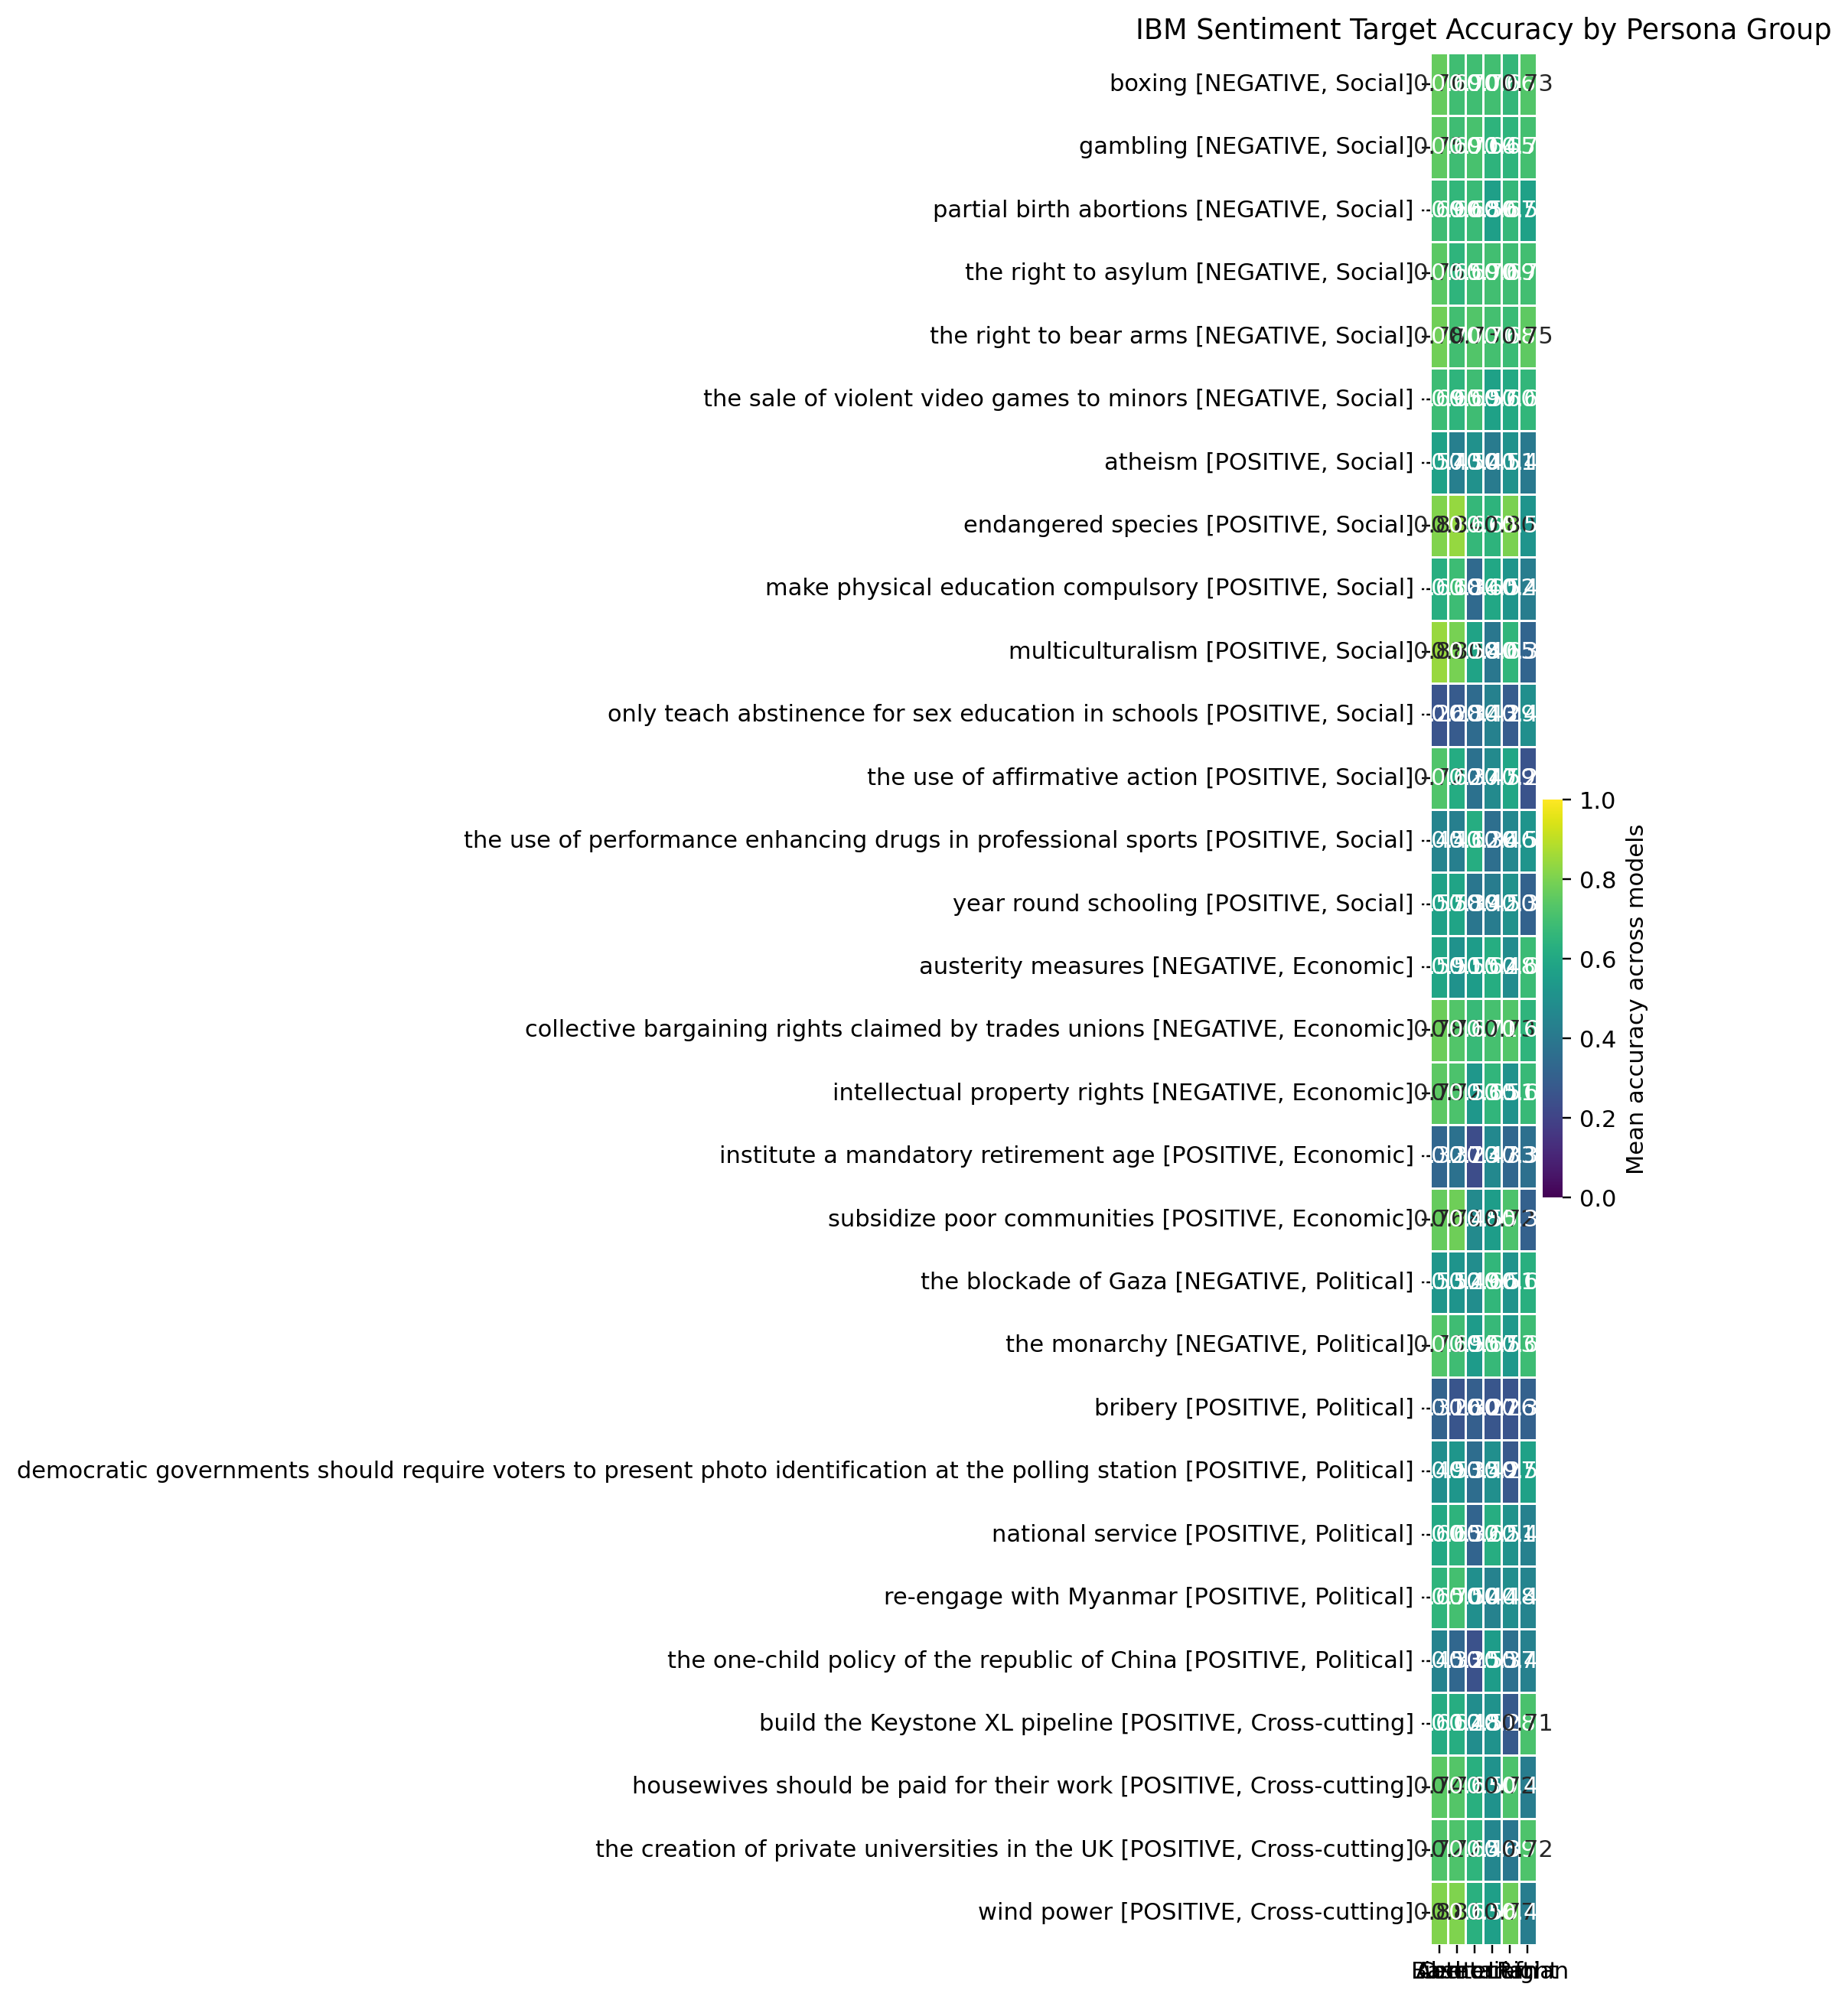

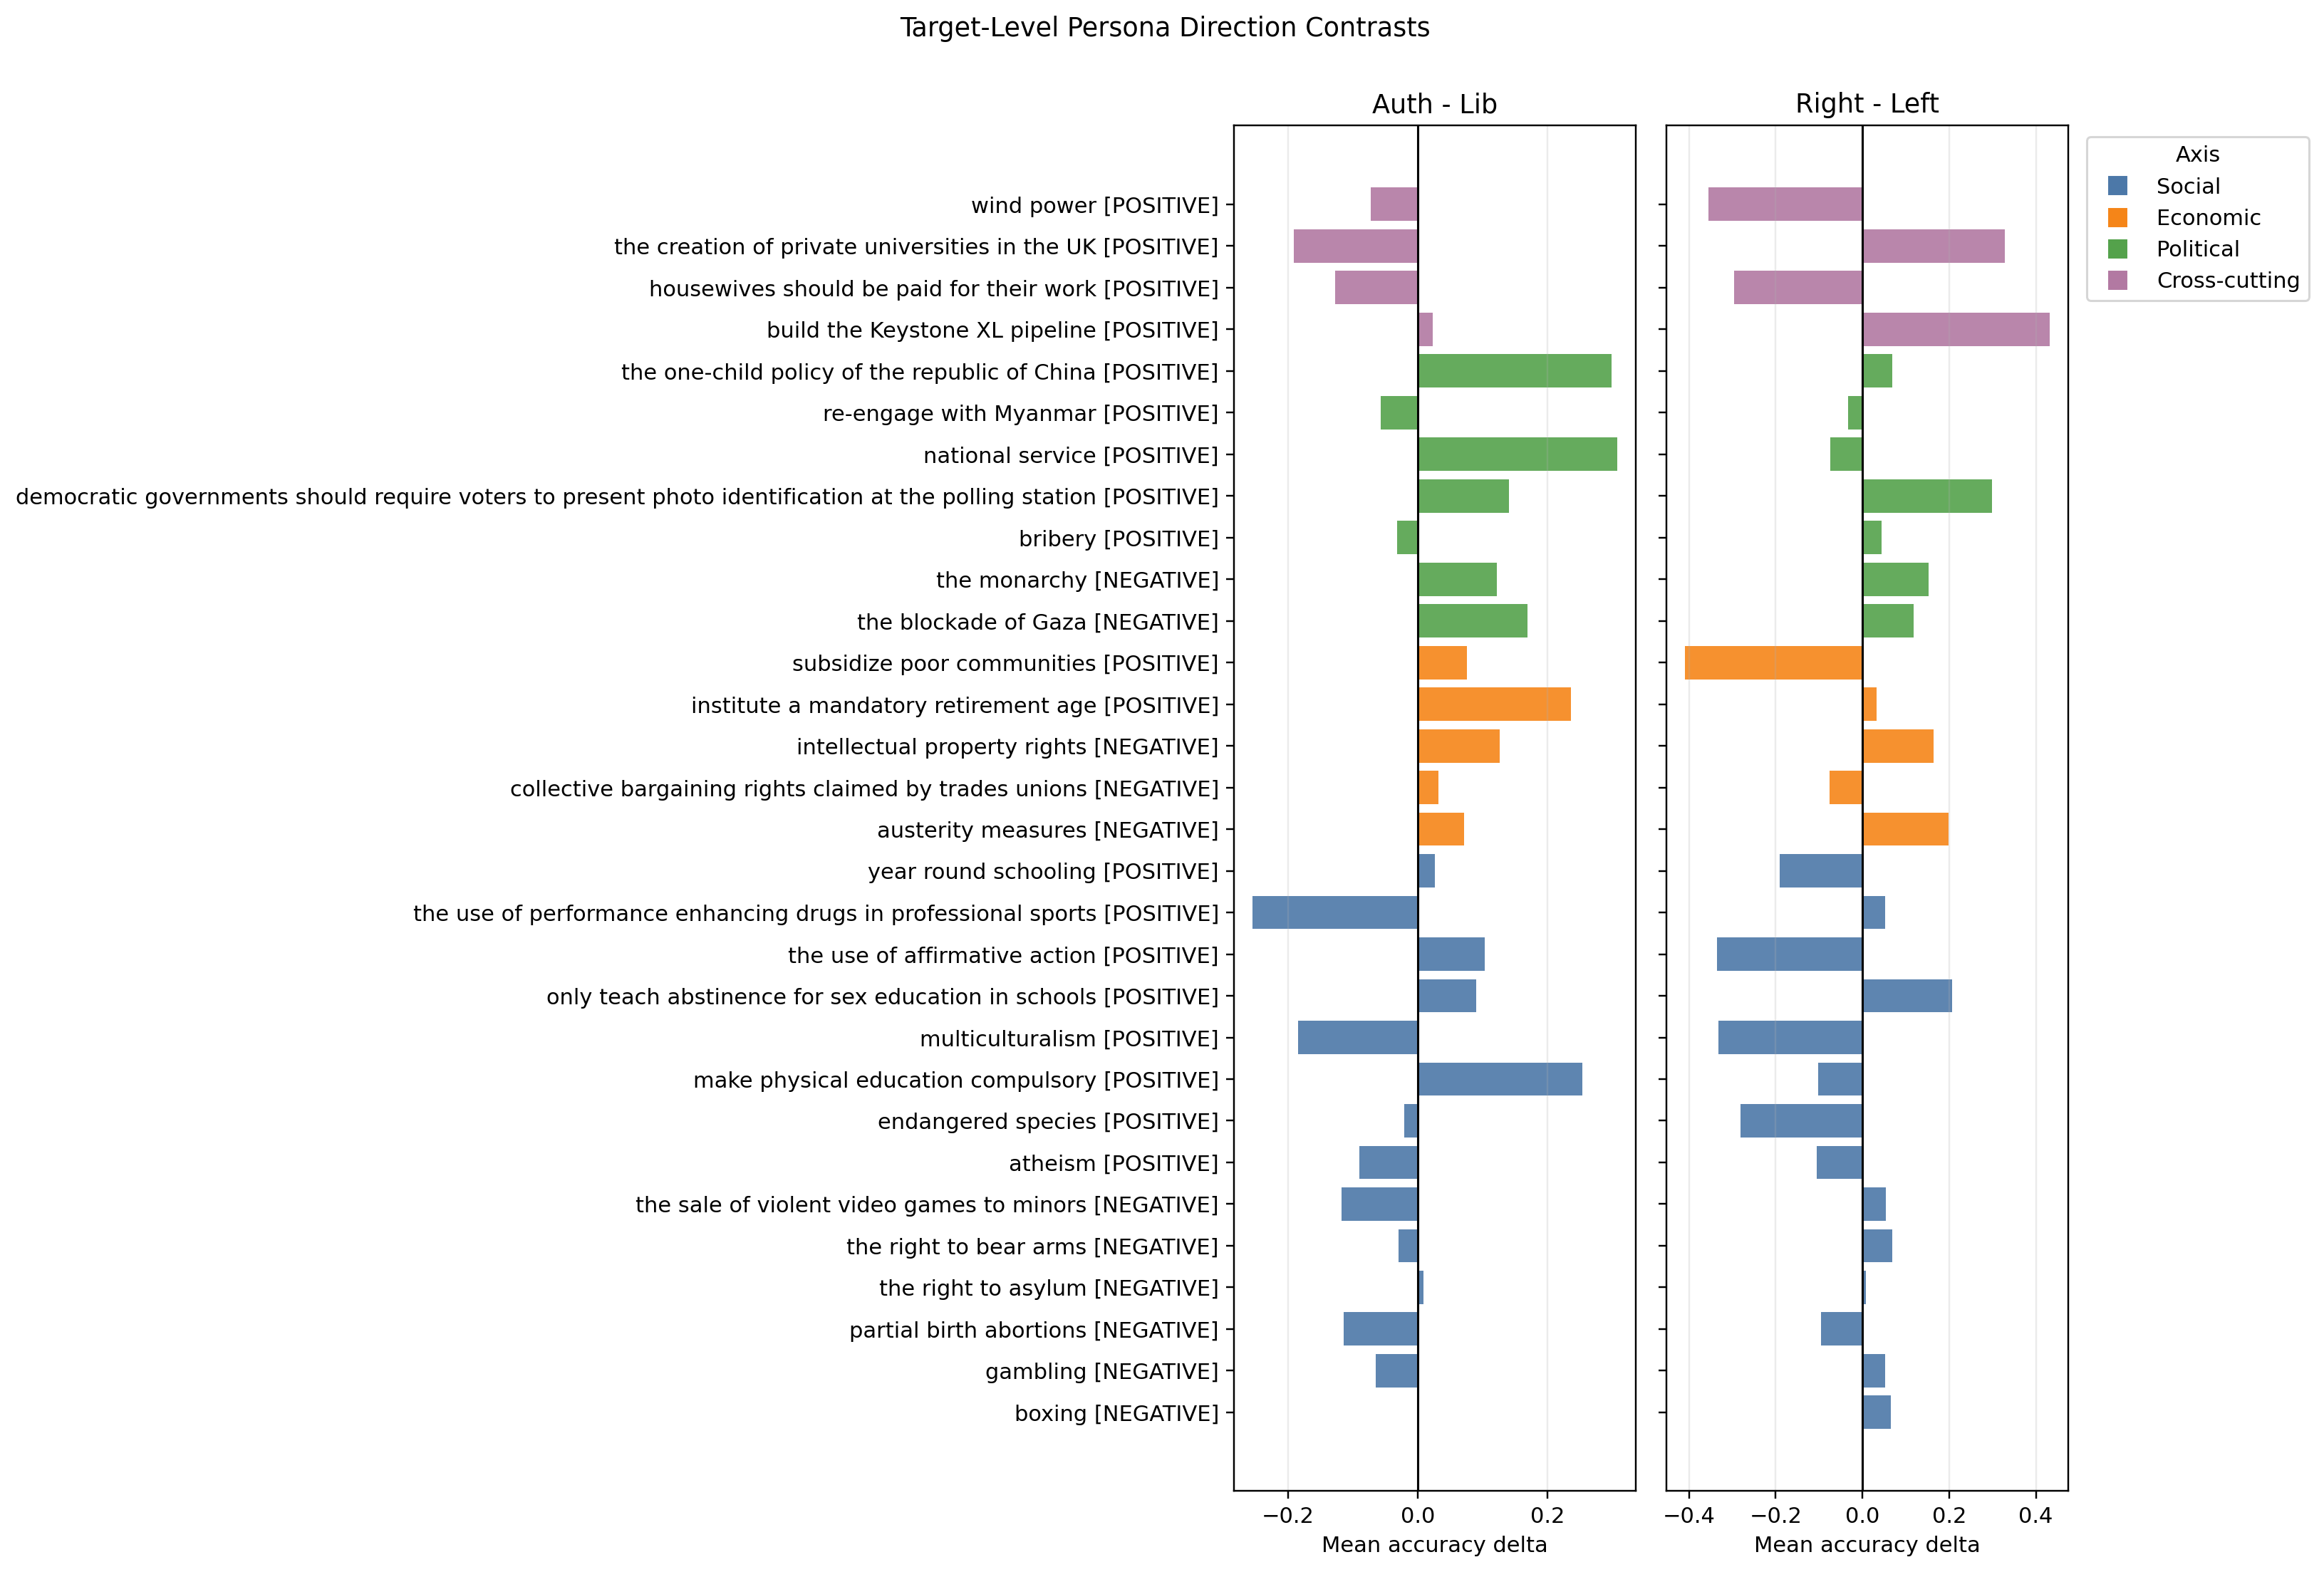

In [24]:
heat = (
    group_scores.groupby(["target", "axis", "gold_label", "persona_group"], observed=True)["item_accuracy"]
    .mean()
    .reset_index()
)
target_order_df = (
    heat.drop_duplicates(["target", "axis", "gold_label"])
    .assign(axis_order=lambda d: d["axis"].map({axis: i for i, axis in enumerate(AXIS_ORDER)}).fillna(99))
    .sort_values(["axis_order", "gold_label", "target"])
)
target_order = target_order_df["target"].tolist()
heat["target_label"] = heat["target"] + " [" + heat["gold_label"] + ", " + heat["axis"] + "]"
target_label_order = (
    target_order_df["target"] + " [" + target_order_df["gold_label"] + ", " + target_order_df["axis"] + "]"
).tolist()
matrix = heat.pivot_table(index="target_label", columns="persona_group", values="item_accuracy", aggfunc="mean")
matrix = matrix.reindex(target_label_order)
matrix = matrix[[col for col in PERSONA_GROUPS.keys() if col in matrix.columns]]

fig, ax = plt.subplots(figsize=(9.5, 12))
sns.heatmap(
    matrix,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean accuracy across models"},
    ax=ax,
)
ax.set_title("IBM Sentiment Target Accuracy by Persona Group")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
out_path = PLOTS_DIR / "03_target_persona_group_accuracy_heatmap.png"
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(out_path)))

plot_df = pd.concat([
    auth_lib.assign(contrast_short="Auth - Lib"),
    right_left.assign(contrast_short="Right - Left"),
], ignore_index=True)
plot_df["target_label"] = plot_df["target"] + " [" + plot_df["gold_label"] + "]"
plot_df["target_label"] = pd.Categorical(plot_df["target_label"], categories=[
    t + " [" + g + "]"
    for t, g in zip(target_order_df["target"], target_order_df["gold_label"])
], ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
for ax, contrast_short in zip(axes, ["Auth - Lib", "Right - Left"]):
    sub = plot_df[plot_df["contrast_short"] == contrast_short].sort_values("target_label")
    colors = sub["axis"].map(AXIS_COLORS).fillna(AXIS_COLORS["Unmapped"])
    ax.barh(sub["target_label"].astype(str), sub["delta"], color=colors, alpha=0.9)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(contrast_short)
    ax.set_xlabel("Mean accuracy delta")
    ax.grid(axis="x", alpha=0.25)
axes[0].set_ylabel("")
handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=10, label=axis)
    for axis, color in AXIS_COLORS.items()
    if axis in set(plot_df["axis"])
]
axes[1].legend(handles=handles, title="Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Target-Level Persona Direction Contrasts", y=1.0)
fig.tight_layout()
out_path = PLOTS_DIR / "04_target_auth_lib_right_left_deltas.png"
fig.savefig(out_path, dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(out_path)))

## Prediction-Skew Diagnostics

Accuracy deltas alone do not say how a persona fails. This section checks whether a group becomes more or less likely to predict `POSITIVE`. For a positive gold topic, lower positive prediction rate is a negative-sentiment bias. For a negative gold topic, higher positive prediction rate is a positive-sentiment false-positive tendency.

In [25]:
def make_group_thresholds(df: pd.DataFrame) -> pd.DataFrame:
    id_cols = ["model", "target"]
    keep_cols = [
        "accuracy",
        "positive_pred_rate",
        "positive_gold_rate",
        "positive_skew",
        "positive_recall",
        "mean_positive_negative_margin",
    ]
    rows = []
    for group, ideologies in PERSONA_GROUPS.items():
        sub = df[df["ideology"].astype(str).isin(ideologies)].copy()
        metric_cols = [col for col in keep_cols if col in sub.columns]
        grouped = sub.groupby(id_cols, observed=True)[metric_cols].mean().reset_index()
        grouped["persona_group"] = group
        rows.append(grouped)
    return pd.concat(rows, ignore_index=True)


threshold_group = make_group_thresholds(threshold_target)
threshold_group = threshold_group.merge(
    item_acc.drop_duplicates(["target"])[["target", "item_index", "axis", "domain", "keyword_primary_label", "gold_label"]],
    on="target",
    how="left",
)

wide_threshold = threshold_group.pivot_table(
    index=["model", "item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label"],
    columns="persona_group",
    values="positive_pred_rate",
    aggfunc="mean",
).reset_index()
wide_threshold.columns.name = None

skew_rows = []
for left, right in COMPARISONS:
    if left not in wide_threshold.columns or right not in wide_threshold.columns:
        continue
    tmp = wide_threshold[["model", "item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label", left, right]].copy()
    tmp["contrast"] = f"{left} - {right}"
    tmp["positive_pred_rate_delta"] = tmp[left] - tmp[right]
    topic = (
        tmp.groupby(["contrast", "item_index", "target", "axis", "domain", "keyword_primary_label", "gold_label"], observed=True)
        .agg(
            left_positive_pred_rate=(left, "mean"),
            right_positive_pred_rate=(right, "mean"),
            positive_pred_rate_delta=("positive_pred_rate_delta", "mean"),
            n_models=("model", "nunique"),
            models_left_more_positive=("positive_pred_rate_delta", lambda s: int(np.sum(np.asarray(s) > 0))),
            models_right_more_positive=("positive_pred_rate_delta", lambda s: int(np.sum(np.asarray(s) < 0))),
        )
        .reset_index()
    )
    skew_rows.append(topic)

target_skew = pd.concat(skew_rows, ignore_index=True)
target_skew["left_more_positive_share"] = target_skew["models_left_more_positive"] / target_skew["n_models"].replace(0, np.nan)
target_skew["right_more_positive_share"] = target_skew["models_right_more_positive"] / target_skew["n_models"].replace(0, np.nan)
write_table(target_skew, "target_positive_prediction_rate_pairwise_deltas.csv")

audit = target_rules.merge(
    target_skew[[
        "contrast", "target", "positive_pred_rate_delta",
        "left_positive_pred_rate", "right_positive_pred_rate",
        "left_more_positive_share", "right_more_positive_share",
    ]],
    on=["contrast", "target"],
    how="left",
)
audit["error_direction_hint"] = np.select(
    [
        (audit["gold_label"] == "POSITIVE") & (audit["delta"] < 0) & (audit["positive_pred_rate_delta"] < 0),
        (audit["gold_label"] == "POSITIVE") & (audit["delta"] > 0) & (audit["positive_pred_rate_delta"] > 0),
        (audit["gold_label"] == "NEGATIVE") & (audit["delta"] < 0) & (audit["positive_pred_rate_delta"] > 0),
        (audit["gold_label"] == "NEGATIVE") & (audit["delta"] > 0) & (audit["positive_pred_rate_delta"] < 0),
    ],
    [
        "left_underpredicts_positive_vs_reference",
        "left_recovers_positive_vs_reference",
        "left_overpredicts_positive_vs_reference",
        "left_reduces_false_positive_vs_reference",
    ],
    default="mixed_or_not_directional",
)
write_table(audit, "target_work_fail_with_positive_skew_hints.csv")

display(Markdown("### Persona failures with likely prediction-skew direction"))
display(audit[(audit["pattern"] == "fails_vs_reference") & audit["contrast"].isin([
    "Libertarian - Base", "Authoritarian - Base", "Left - Base", "Right - Base",
    "Libertarian - Center", "Authoritarian - Center", "Left - Center", "Right - Center",
])].sort_values("delta")[[
    "contrast", "target", "axis", "gold_label", "delta", "positive_pred_rate_delta",
    "left_positive_pred_rate", "right_positive_pred_rate", "error_direction_hint",
]].head(50))

display(Markdown("### Authoritarian vs libertarian prediction-skew contrast"))
display(audit[audit["contrast"] == "Authoritarian - Libertarian"].sort_values("delta")[[
    "target", "axis", "gold_label", "delta", "positive_pred_rate_delta",
    "left_positive_pred_rate", "right_positive_pred_rate", "error_direction_hint",
]])

### Persona failures with likely prediction-skew direction

,contrast,target,axis,gold_label,delta,positive_pred_rate_delta,left_positive_pred_rate,right_positive_pred_rate,error_direction_hint
126,Right - Base,multiculturalism,Social,POSITIVE,-0.523750,-0.523750,0.322500,0.846250,left_underpredicts_positive_vs_reference
246,Right - Center,multiculturalism,Social,POSITIVE,-0.472917,-0.472917,0.322500,0.795417,left_underpredicts_positive_vs_reference
253,Right - Center,subsidize poor communities,Economic,POSITIVE,-0.471042,-0.471042,0.308542,0.779583,left_underpredicts_positive_vs_reference
124,Right - Base,the use of affirmative action,Social,POSITIVE,-0.468542,-0.468542,0.255625,0.724167,left_underpredicts_positive_vs_reference
133,Right - Base,subsidize poor communities,Economic,POSITIVE,-0.453958,-0.453958,0.308542,0.762500,left_underpredicts_positive_vs_reference
66,Authoritarian - Base,multiculturalism,Social,POSITIVE,-0.450000,-0.450000,0.396250,0.846250,left_underpredicts_positive_vs_reference
186,Authoritarian - Center,multiculturalism,Social,POSITIVE,-0.399167,-0.399167,0.396250,0.795417,left_underpredicts_positive_vs_reference
140,Right - Base,wind power,Cross-cutting,POSITIVE,-0.392083,-0.392083,0.420000,0.812083,left_underpredicts_positive_vs_reference
260,Right - Center,wind power,Cross-cutting,POSITIVE,-0.385417,-0.385417,0.420000,0.805417,left_underpredicts_positive_vs_reference
244,Right - Center,the use of affirmative action,Social,POSITIVE,-0.361458,-0.361458,0.255625,0.617083,left_underpredicts_positive_vs_reference


### Authoritarian vs libertarian prediction-skew contrast

,target,axis,gold_label,delta,positive_pred_rate_delta,left_positive_pred_rate,right_positive_pred_rate,error_direction_hint
272,the use of performance enhancing drugs in prof...,Social,POSITIVE,-0.254792,-0.254792,0.362500,0.617292,left_underpredicts_positive_vs_reference
298,the creation of private universities in the UK,Cross-cutting,POSITIVE,-0.190833,-0.190833,0.460625,0.651458,left_underpredicts_positive_vs_reference
276,multiculturalism,Social,POSITIVE,-0.184792,-0.184792,0.396250,0.581042,left_underpredicts_positive_vs_reference
288,housewives should be paid for their work,Cross-cutting,POSITIVE,-0.127917,-0.127917,0.504375,0.632292,left_underpredicts_positive_vs_reference
270,the sale of violent video games to minors,Social,NEGATIVE,-0.118125,0.118125,0.426875,0.308750,left_overpredicts_positive_vs_reference
281,partial birth abortions,Social,NEGATIVE,-0.114375,0.114375,0.438125,0.323750,left_overpredicts_positive_vs_reference
284,atheism,Social,POSITIVE,-0.090417,-0.090417,0.413125,0.503542,left_underpredicts_positive_vs_reference
290,wind power,Cross-cutting,POSITIVE,-0.073125,-0.073125,0.560833,0.633958,left_underpredicts_positive_vs_reference
277,gambling,Social,NEGATIVE,-0.065000,0.065000,0.355417,0.290417,left_overpredicts_positive_vs_reference
295,re-engage with Myanmar,Political,POSITIVE,-0.057083,-0.057083,0.438958,0.496042,left_underpredicts_positive_vs_reference


## Domain and Target-Group Checks

The paper should not rely heavily on these finer groupings, but they are useful for deciding whether the broad-axis story is hiding one or two specific topic clusters. Treat this as exploratory because support can be very small.

In [26]:
domain_tests = summarize_deltas(group_topic_deltas, ["contrast", "left", "right", "domain"])
keyword_tests = summarize_deltas(group_topic_deltas, ["contrast", "left", "right", "keyword_primary_label"])
write_table(domain_tests, "domain_group_pairwise_topic_tests_exploratory.csv")
write_table(keyword_tests, "keyword_group_pairwise_topic_tests_exploratory.csv")

display(Markdown("### Domain-level largest absolute contrasts"))
display(domain_tests.assign(abs_delta=lambda d: d["mean_delta"].abs()).sort_values("abs_delta", ascending=False)[[
    "contrast", "domain", "n_units", "mean_delta", "ci_low", "ci_high",
    "positive_delta_share", "signflip_p_value", "q_value_bh",
]].head(40))

display(Markdown("### Keyword-group largest absolute contrasts"))
display(keyword_tests.assign(abs_delta=lambda d: d["mean_delta"].abs()).sort_values("abs_delta", ascending=False)[[
    "contrast", "keyword_primary_label", "n_units", "mean_delta", "ci_low", "ci_high",
    "positive_delta_share", "signflip_p_value", "q_value_bh",
]].head(40))

### Domain-level largest absolute contrasts

,contrast,domain,n_units,mean_delta,ci_low,ci_high,positive_delta_share,signflip_p_value,q_value_bh
105,Right - Base,Race / Ethnicity / Minority Policy,2,-0.496146,-0.523750,-0.468542,0.000000,0.500875,0.740630
117,Right - Center,Race / Ethnicity / Minority Policy,2,-0.417188,-0.472917,-0.361458,0.000000,0.500875,0.740630
9,Authoritarian - Base,Race / Ethnicity / Minority Policy,2,-0.349792,-0.450000,-0.249583,0.000000,0.500875,0.740630
129,Right - Left,Race / Ethnicity / Minority Policy,2,-0.333750,-0.335208,-0.332292,0.000000,0.500875,0.740630
81,Libertarian - Base,Race / Ethnicity / Minority Policy,2,-0.308750,-0.352292,-0.265208,0.000000,0.500875,0.740630
21,Authoritarian - Center,Race / Ethnicity / Minority Policy,2,-0.270833,-0.399167,-0.142500,0.000000,0.500875,0.740630
56,Left - Base,Markets / Property / Private Sector,1,-0.240625,-0.240625,-0.240625,0.000000,NaN,NaN
93,Libertarian - Center,Race / Ethnicity / Minority Policy,2,-0.229792,-0.245208,-0.214375,0.000000,0.500875,0.740630
80,Libertarian - Base,Markets / Property / Private Sector,1,-0.221250,-0.221250,-0.221250,0.000000,NaN,NaN
68,Left - Center,Markets / Property / Private Sector,1,-0.208542,-0.208542,-0.208542,0.000000,NaN,NaN


### Keyword-group largest absolute contrasts

,contrast,keyword_primary_label,n_units,mean_delta,ci_low,ci_high,positive_delta_share,signflip_p_value,q_value_bh
113,Right - Base,Race / Ethnicity / Minority Policy,2,-0.496146,-0.523750,-0.468542,0.000000,0.500875,0.716738
126,Right - Center,Race / Ethnicity / Minority Policy,2,-0.417188,-0.472917,-0.361458,0.000000,0.500875,0.716738
9,Authoritarian - Base,Race / Ethnicity / Minority Policy,2,-0.349792,-0.450000,-0.249583,0.000000,0.500875,0.716738
139,Right - Left,Race / Ethnicity / Minority Policy,2,-0.333750,-0.335208,-0.332292,0.000000,0.500875,0.716738
102,Libertarian - Center,Security / Order / Authority,1,-0.328125,-0.328125,-0.328125,0.000000,NaN,NaN
87,Libertarian - Base,Race / Ethnicity / Minority Policy,2,-0.308750,-0.352292,-0.265208,0.000000,0.500875,0.716738
37,Authoritarian - Libertarian,Security / Order / Authority,1,0.307083,0.307083,0.307083,1.000000,NaN,NaN
89,Libertarian - Base,Security / Order / Authority,1,-0.283125,-0.283125,-0.283125,0.000000,NaN,NaN
22,Authoritarian - Center,Race / Ethnicity / Minority Policy,2,-0.270833,-0.399167,-0.142500,0.000000,0.500875,0.716738
60,Left - Base,Markets / Property / Private Sector,1,-0.240625,-0.240625,-0.240625,0.000000,NaN,NaN


## ELI5: Why the Persona Heatmap Looks Different from the Delta Plots

The heatmap and the delta plots are answering different questions.

The heatmap asks: **How good is this exact model under this exact persona?** Each cell is an absolute macro-F1 score. It correctly shows a bright-to-dim pattern: base and center are high, ideological personas are lower.

The delta plots ask: **After collapsing personas into families and comparing one family against another, which side is less damaged?** For example, `Authoritarian - Libertarian` does not compare authoritarian against base. It compares two already-degraded persona families. A positive value only means authoritarian is less bad than libertarian on that slice.

This section reconciles the two views by computing:

- heatmap-style macro-F1 deltas;
- family-collapsed macro-F1 deltas;
- family-collapsed topic-accuracy deltas;
- axis support contributions to each overall contrast.

In [27]:
heatmap_wide = summary_ideology.pivot(index="model", columns="ideology", values="macro_f1")
heatmap_wide = heatmap_wide.reindex(MODEL_ORDER)

display(Markdown("### Heatmap-style macro-F1 deltas against base"))
heatmap_delta_rows = []
for persona in ["centrism", "libertarian_left", "libertarian_right", "authoritarian_left", "authoritarian_right"]:
    delta = heatmap_wide[persona] - heatmap_wide["base"]
    heatmap_delta_rows.append({
        "contrast": f"{persona} - base",
        "mean_macro_f1_delta": delta.mean(),
        "min_model_delta": delta.min(),
        "max_model_delta": delta.max(),
        "models_above_base": int((delta > 0).sum()),
        "models_below_base": int((delta < 0).sum()),
    })
heatmap_delta = pd.DataFrame(heatmap_delta_rows)
write_table(heatmap_delta, "heatmap_style_macro_f1_deltas_vs_base.csv")
display(heatmap_delta)

display(Markdown("### Heatmap-style macro-F1 deltas against center"))
heatmap_center_rows = []
for persona in ["libertarian_left", "libertarian_right", "authoritarian_left", "authoritarian_right"]:
    delta = heatmap_wide[persona] - heatmap_wide["centrism"]
    heatmap_center_rows.append({
        "contrast": f"{persona} - centrism",
        "mean_macro_f1_delta": delta.mean(),
        "min_model_delta": delta.min(),
        "max_model_delta": delta.max(),
        "models_above_center": int((delta > 0).sum()),
        "models_below_center": int((delta < 0).sum()),
    })
heatmap_center_delta = pd.DataFrame(heatmap_center_rows)
write_table(heatmap_center_delta, "heatmap_style_macro_f1_deltas_vs_center.csv")
display(heatmap_center_delta)

family_macro = pd.DataFrame({
    family: heatmap_wide[ideologies].mean(axis=1)
    for family, ideologies in PERSONA_GROUPS.items()
})
family_macro = family_macro.reindex(MODEL_ORDER)
family_macro_mean = (
    family_macro.mean()
    .rename("mean_macro_f1")
    .reset_index()
    .rename(columns={"index": "persona_group"})
    .sort_values("mean_macro_f1", ascending=False)
)
write_table(family_macro_mean, "family_collapsed_macro_f1_means.csv")
display(Markdown("### Family-collapsed macro-F1 means"))
display(family_macro_mean)

family_macro_delta_rows = []
for left, right in [
    ("Libertarian", "Base"),
    ("Authoritarian", "Base"),
    ("Left", "Base"),
    ("Right", "Base"),
    ("Authoritarian", "Libertarian"),
    ("Right", "Left"),
]:
    delta = family_macro[left] - family_macro[right]
    family_macro_delta_rows.append({
        "contrast": f"{left} - {right}",
        "mean_macro_f1_delta": delta.mean(),
        "min_model_delta": delta.min(),
        "max_model_delta": delta.max(),
        "models_positive": int((delta > 0).sum()),
        "models_negative": int((delta < 0).sum()),
    })
family_macro_deltas = pd.DataFrame(family_macro_delta_rows)
write_table(family_macro_deltas, "family_collapsed_macro_f1_deltas.csv")
display(Markdown("### Family-collapsed macro-F1 deltas"))
display(family_macro_deltas)

display(Markdown("### Same family contrasts using topic-level accuracy"))
topic_accuracy_deltas = overall_topic[
    overall_topic["contrast"].isin(family_macro_deltas["contrast"])
][[
    "contrast", "n_units", "mean_delta", "ci_low", "ci_high",
    "positive_delta_share", "q_value_bh",
]].copy()
write_table(topic_accuracy_deltas, "family_collapsed_topic_accuracy_deltas.csv")
display(topic_accuracy_deltas.sort_values("mean_delta"))

### Heatmap-style macro-F1 deltas against base

,contrast,mean_macro_f1_delta,min_model_delta,max_model_delta,models_above_base,models_below_base
0,centrism - base,-0.028102,-0.065638,-0.001193,0,8
1,libertarian_left - base,-0.109466,-0.196361,-0.008307,0,8
2,libertarian_right - base,-0.121755,-0.213458,-0.010321,0,8
3,authoritarian_left - base,-0.089018,-0.139003,-0.006108,0,8
4,authoritarian_right - base,-0.094701,-0.180503,-0.003612,0,8


### Heatmap-style macro-F1 deltas against center

,contrast,mean_macro_f1_delta,min_model_delta,max_model_delta,models_above_center,models_below_center
0,libertarian_left - centrism,-0.081364,-0.130723,-0.005549,0,8
1,libertarian_right - centrism,-0.093653,-0.148119,-0.007563,0,8
2,authoritarian_left - centrism,-0.060916,-0.104292,-0.003351,0,8
3,authoritarian_right - centrism,-0.066599,-0.114865,-0.000855,0,8


### Family-collapsed macro-F1 means

,persona_group,mean_macro_f1
0,Base,0.631587
1,Center,0.603485
3,Authoritarian,0.539728
4,Left,0.532345
5,Right,0.523359
2,Libertarian,0.515977


### Family-collapsed macro-F1 deltas

,contrast,mean_macro_f1_delta,min_model_delta,max_model_delta,models_positive,models_negative
0,Libertarian - Base,-0.115610,-0.204909,-0.009314,0,8
1,Authoritarian - Base,-0.091859,-0.159753,-0.004860,0,8
2,Left - Base,-0.099242,-0.167682,-0.007208,0,8
3,Right - Base,-0.108228,-0.196980,-0.006966,0,8
4,Authoritarian - Libertarian,0.023751,-0.006008,0.052718,7,1
5,Right - Left,-0.008986,-0.029298,0.006234,3,5


### Same family contrasts using topic-level accuracy

,contrast,n_units,mean_delta,ci_low,ci_high,positive_delta_share,q_value_bh
6,Libertarian - Base,30,-0.117146,-0.157292,-0.077325,0.100000,0.000275
8,Right - Base,30,-0.110743,-0.179180,-0.047159,0.233333,0.005041
4,Left - Base,30,-0.099465,-0.133431,-0.068569,0.100000,0.000275
0,Authoritarian - Base,30,-0.093063,-0.140889,-0.044180,0.233333,0.001925
10,Right - Left,30,-0.011278,-0.086355,0.062728,0.566667,0.774911
2,Authoritarian - Libertarian,30,0.024083,-0.025271,0.076091,0.566667,0.401315


In [28]:
display(Markdown("### Does axis/topic support explain the aggregate direction?"))
axis_contrib = axis_tests[
    axis_tests["contrast"].isin([
        "Libertarian - Base",
        "Authoritarian - Base",
        "Authoritarian - Libertarian",
        "Right - Left",
    ])
].copy()
axis_contrib["topic_weight"] = axis_contrib["n_units"] / 30.0
axis_contrib["weighted_contribution"] = axis_contrib["mean_delta"] * axis_contrib["topic_weight"]
axis_contrib = axis_contrib.sort_values(["contrast", "axis"])
write_table(axis_contrib, "axis_weight_contributions_to_overall_deltas.csv")
display(axis_contrib[[
    "contrast", "axis", "n_units", "topic_weight", "mean_delta",
    "weighted_contribution", "ci_low", "ci_high",
]])

contrib_check = (
    axis_contrib.groupby("contrast", observed=True)
    .agg(
        reconstructed_overall_delta=("weighted_contribution", "sum"),
        total_topics=("n_units", "sum"),
    )
    .reset_index()
)
write_table(contrib_check, "axis_weight_contribution_checks.csv")
display(Markdown("### Reconstructed overall deltas from axis contributions"))
display(contrib_check)

display(Markdown(
    "Interpretation: axis support matters for the aggregate contrast because Social topics are 14/30 of the benchmark. "
    "For `Authoritarian - Libertarian`, political and economic topics push the mean positive, while Social and Cross-cutting push it negative. "
    "The net result is therefore small even though individual axis bars can look large."
))

### Does axis/topic support explain the aggregate direction?

,contrast,axis,n_units,topic_weight,mean_delta,weighted_contribution,ci_low,ci_high
3,Authoritarian - Base,Social,14,0.466667,-0.119554,-0.055792,-0.189821,-0.054182
1,Authoritarian - Base,Economic,5,0.166667,-0.040833,-0.006806,-0.139542,0.056583
2,Authoritarian - Base,Political,7,0.233333,-0.008036,-0.001875,-0.090208,0.065625
0,Authoritarian - Base,Cross-cutting,4,0.133333,-0.214427,-0.028590,-0.257292,-0.140469
11,Authoritarian - Libertarian,Social,14,0.466667,-0.028289,-0.013201,-0.090536,0.040166
9,Authoritarian - Libertarian,Economic,5,0.166667,0.108083,0.018014,0.056500,0.172833
10,Authoritarian - Libertarian,Political,7,0.233333,0.135327,0.031576,0.034345,0.232351
8,Authoritarian - Libertarian,Cross-cutting,4,0.133333,-0.092292,-0.012306,-0.161406,-0.014948
27,Libertarian - Base,Social,14,0.466667,-0.091265,-0.042590,-0.164392,-0.021265
25,Libertarian - Base,Economic,5,0.166667,-0.148917,-0.024819,-0.235125,-0.074000


### Reconstructed overall deltas from axis contributions

,contrast,reconstructed_overall_delta,total_topics
0,Authoritarian - Base,-0.093063,30
1,Authoritarian - Libertarian,0.024083,30
2,Libertarian - Base,-0.117146,30
3,Right - Left,-0.011278,30


Interpretation: axis support matters for the aggregate contrast because Social topics are 14/30 of the benchmark. For `Authoritarian - Libertarian`, political and economic topics push the mean positive, while Social and Cross-cutting push it negative. The net result is therefore small even though individual axis bars can look large.

## Paper-Safe Interpretation Checklist

This cell writes a compact evidence table that should be used before editing the manuscript. Suggested interpretation rules:

- If topic-level `q_value_bh` is not below 0.05, phrase the result as an observed tendency, not as a statistically reliable difference.
- If the mean delta is under roughly 0.02-0.03 accuracy points, avoid treating it as substantively meaningful even if the sign is consistent.
- If `Base` and `Center` beat both ideological families, the safer story is persona steering degradation rather than one ideology being intrinsically better.
- If an axis has fewer than 5 topics, present it as descriptive only.
- If a target contrast is driven by a single topic class, use it as intuition/example, not as an aggregate claim.

In [29]:
def evidence_label(row: pd.Series) -> str:
    mean_delta = row.get("mean_delta", np.nan)
    q = row.get("q_value_bh", np.nan)
    n = row.get("n_units", 0)
    if pd.isna(mean_delta):
        return "insufficient"
    if n < 5:
        return "low_support_descriptive"
    if abs(mean_delta) < 0.02:
        return "tiny_effect"
    if pd.notna(q) and q < 0.05 and abs(mean_delta) >= 0.03:
        return "statistically_supported_moderate_effect"
    if abs(mean_delta) >= 0.05:
        return "large_descriptive_effect_needs_caution"
    return "small_descriptive_effect"


paper_evidence = overall_topic.copy()
paper_evidence["evidence_label"] = paper_evidence.apply(evidence_label, axis=1)
axis_evidence = axis_tests.copy()
axis_evidence["evidence_label"] = axis_evidence.apply(evidence_label, axis=1)

write_table(paper_evidence, "paper_safe_overall_persona_evidence_labels.csv")
write_table(axis_evidence, "paper_safe_axis_persona_evidence_labels.csv")

display(Markdown("### Overall evidence labels"))
display(paper_evidence[[
    "contrast", "n_units", "mean_delta", "ci_low", "ci_high",
    "positive_delta_share", "signflip_p_value", "q_value_bh", "evidence_label",
]].sort_values("mean_delta"))

display(Markdown("### Axis evidence labels"))
display(axis_evidence[[
    "contrast", "axis", "n_units", "mean_delta", "ci_low", "ci_high",
    "positive_delta_share", "signflip_p_value", "q_value_bh", "evidence_label",
]].sort_values(["contrast", "axis"]))

notes = []
notes.append("# IBM Sentiment Bias Paper Audit: Auto-Summary\n")
notes.append("This file is generated by `analysis-ibm-sentiment-bias-paper.ipynb`. Review after executing the notebook.\n")
notes.append("## Overall group comparisons\n")
notes.append(paper_evidence.sort_values("mean_delta").to_markdown(index=False))
notes.append("\n\n## Axis group comparisons\n")
notes.append(axis_evidence.sort_values(["contrast", "axis"]).to_markdown(index=False))
summary_path = OUTPUT_DIR / "ibm_sentiment_bias_paper_audit_auto_summary.md"
summary_path.write_text("\n".join(notes), encoding="utf-8")
display(Markdown(f"Wrote `{summary_path}`."))

### Overall evidence labels

,contrast,n_units,mean_delta,ci_low,ci_high,positive_delta_share,signflip_p_value,q_value_bh,evidence_label
6,Libertarian - Base,30,-0.117146,-0.157292,-0.077325,0.100000,0.000050,0.000275,statistically_supported_moderate_effect
8,Right - Base,30,-0.110743,-0.179180,-0.047159,0.233333,0.002750,0.005041,statistically_supported_moderate_effect
4,Left - Base,30,-0.099465,-0.133431,-0.068569,0.100000,0.000050,0.000275,statistically_supported_moderate_effect
0,Authoritarian - Base,30,-0.093063,-0.140889,-0.044180,0.233333,0.000700,0.001925,statistically_supported_moderate_effect
7,Libertarian - Center,30,-0.091049,-0.138092,-0.045368,0.366667,0.000900,0.001980,statistically_supported_moderate_effect
9,Right - Center,30,-0.084646,-0.155473,-0.018104,0.433333,0.023649,0.028904,statistically_supported_moderate_effect
5,Left - Center,30,-0.073368,-0.112820,-0.037736,0.200000,0.000250,0.000917,statistically_supported_moderate_effect
1,Authoritarian - Center,30,-0.066965,-0.116737,-0.016812,0.300000,0.014249,0.019593,statistically_supported_moderate_effect
3,Center - Base,30,-0.026097,-0.045029,-0.008124,0.333333,0.011799,0.018542,small_descriptive_effect
10,Right - Left,30,-0.011278,-0.086355,0.062728,0.566667,0.774911,0.774911,tiny_effect


### Axis evidence labels

,contrast,axis,n_units,mean_delta,ci_low,ci_high,positive_delta_share,signflip_p_value,q_value_bh,evidence_label
3,Authoritarian - Base,Social,14,-0.119554,-0.189821,-0.054182,0.071429,0.003800,0.083596,large_descriptive_effect_needs_caution
1,Authoritarian - Base,Economic,5,-0.040833,-0.139542,0.056583,0.400000,0.559822,0.685938,small_descriptive_effect
2,Authoritarian - Base,Political,7,-0.008036,-0.090208,0.065625,0.571429,0.892405,0.913159,tiny_effect
0,Authoritarian - Base,Cross-cutting,4,-0.214427,-0.257292,-0.140469,0.000000,0.125794,0.224389,low_support_descriptive
7,Authoritarian - Center,Social,14,-0.077381,-0.146193,-0.016114,0.285714,0.033948,0.186716,large_descriptive_effect_needs_caution
5,Authoritarian - Center,Economic,5,-0.021583,-0.130833,0.078125,0.400000,0.809860,0.890845,small_descriptive_effect
6,Authoritarian - Center,Political,7,0.004345,-0.098575,0.105625,0.428571,0.984551,0.984551,tiny_effect
4,Authoritarian - Center,Cross-cutting,4,-0.212031,-0.253125,-0.146615,0.000000,0.125794,0.224389,low_support_descriptive
11,Authoritarian - Libertarian,Social,14,-0.028289,-0.090536,0.040166,0.428571,0.424579,0.584704,small_descriptive_effect
9,Authoritarian - Libertarian,Economic,5,0.108083,0.056500,0.172833,1.000000,0.063147,0.213728,large_descriptive_effect_needs_caution


Wrote `tasks/stance-sentiment/output/ibm-sentiment-bias-paper/ibm_sentiment_bias_paper_audit_auto_summary.md`.